### Polymarket

In [1]:
import warnings, os, re
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from sklearn.utils.class_weight import compute_class_weight

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# BERT
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f0c29',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ddd',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#eee',
    'grid.color':       '#333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Using device: cpu
PyTorch: 2.2.2+cpu


In [3]:
%run "C:/Users/Melis/OneDrive/Desktop/eda_starter_template.py"


[Memory] Initial memory usage: 588.78 MB

Loading Bitcoin data from C:\Users\Melis\OneDrive\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 588.78 MB
[Memory] After loading Bitcoin data: 592.05 MB (Δ 3.27 MB)
Error loading Bitcoin data: The system cannot find the path specified. (os error 3): C:/Users/Melis/OneDrive/data/Coin Metrics/coinmetrics_btc.csv
Loading Polymarket data from C:\Users\Melis\OneDrive\data\Polymarket...
[Memory] Before loading Polymarket data: 592.06 MB
[Memory] After loading Polymarket data: 592.06 MB (Δ 0.00 MB)

[Memory] Final memory usage: 592.06 MB (Total Δ: 3.28 MB)

EDA Layout Complete. Check the 'plots' directory for visualizations.


In [4]:
%run C:/Users/Melis/OneDrive/Desktop/cap/lse-bitcoin-analytics-capstone-template/data/download_data.py

--- Downloading Capstone Data ---


Retrieving folder contents


Retrieving folder 1SvAwcdegMzgPANM4pnuTH_9DbNEyXt8N BRK Metrics
Processing file 1wtH8dGFqvNco3OcSd5V0sdfJ_NGmiOdB brk_metrics.parquet
Processing file 1PKEehgLbJtSfFsUa3awLLuCkEWfdWF8K brk-metrics-parquet-schema.md
Retrieving folder 1mgd1yrowPdQ0JKtdnKBQYHpvcdyRlXcV Coin Metrics
Processing file 1IUADRKckAZVoFYIJjTt9f_la-CQmnXIN coinmetrics_btc.csv
Processing file 1KVBZIl45-DnY0EzbA6-qFZi7kvu1iH8H coinmetrics_spec.md
Retrieving folder 1f_RjuR2AVTpuJeX6jgeoKcspjUp9_lif Polymarket
Processing file 14v0AUTMO6GwQ4ItLNRI8EuxLXplvCoGt finance_politics_event_stats.parquet
Processing file 1oF4B2zvi21br9a6NFVTwjAB8mfNuLdYx finance_politics_markets.parquet
Processing file 1z4nfPZL04Rkhp82piCvqRFerKBQbrXCh finance_politics_odds_history.parquet
Processing file 1QrWoxsFnfxv7Qs1lR4j2wpTs20MqOLnk finance_politics_summary.parquet
Processing file 1K1DjGkN4fkDMRXqZekS_-vRn-WErRLsz finance_politics_tokens.parquet
Processing file 1GO00RPaS7Q2ncX0fcUHiBLyy4bZR4_Yt finance_politics_trades.parquet
Processing fi

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1wtH8dGFqvNco3OcSd5V0sdfJ_NGmiOdB
From (redirected): https://drive.google.com/uc?id=1wtH8dGFqvNco3OcSd5V0sdfJ_NGmiOdB&confirm=t&uuid=278f82dd-48b7-406e-ba49-6742a04814cb
To: c:\Users\Melis\OneDrive\Desktop\tmp_capstone_data\BRK Metrics\brk_metrics.parquet
100%|██████████| 1.16G/1.16G [01:53<00:00, 10.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PKEehgLbJtSfFsUa3awLLuCkEWfdWF8K
To: c:\Users\Melis\OneDrive\Desktop\tmp_capstone_data\BRK Metrics\brk-metrics-parquet-schema.md
100%|██████████| 9.50k/9.50k [00:00<?, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=1IUADRKckAZVoFYIJjTt9f_la-CQmnXIN
To: c:\Users\Melis\OneDrive\Desktop\tmp_capstone_data\Coin Metrics\coinmetrics_btc.csv
100%|██████████| 2.42M/2.42M [00:00<00:00, 12.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KVBZIl45-DnY0EzbA

Organizing files...
  Keeping: BRK Metrics\brk-metrics-parquet-schema.md
  Keeping: BRK Metrics\brk_metrics.parquet
  Keeping: Coin Metrics\coinmetrics_btc.csv
  Keeping: Coin Metrics\coinmetrics_spec.md
  Keeping: Polymarket\finance_politics_event_stats.parquet
  Keeping: Polymarket\finance_politics_markets.parquet
  Keeping: Polymarket\finance_politics_odds_history.parquet
  Keeping: Polymarket\finance_politics_summary.parquet
  Keeping: Polymarket\finance_politics_tokens.parquet
  Keeping: Polymarket\finance_politics_trades.parquet
  Keeping: Polymarket\polymarket_btc_analytics_schema.md

Successfully organized 11 file(s).
--- Finished downloading ---

Data download and organization complete.


In [5]:
import os
import pandas as pd

COINMETRICS_PATH = r'C:\Users\Melis\OneDrive\Desktop\data\Coin Metrics\coinmetrics_btc.csv'
POLYMARKET_DIR   = r'C:\Users\Melis\OneDrive\Desktop\data\Polymarket'

# Load Bitcoin data
btc_df = load_bitcoin_data(COINMETRICS_PATH)

# Debug: Check directory and files
print("\n" + "="*80)
print("POLYMARKET DATA LOADING")
print("="*80)
print(f"\nDirectory: {POLYMARKET_DIR}")
print(f"Directory exists: {os.path.exists(POLYMARKET_DIR)}")

if os.path.exists(POLYMARKET_DIR):
    print("\nFiles in directory:")
    all_files = os.listdir(POLYMARKET_DIR)
    for file in sorted(all_files):
        filepath = os.path.join(POLYMARKET_DIR, file)
        size = os.path.getsize(filepath) / (1024*1024)  # Size in MB
        print(f"  {file:50s} ({size:.2f} MB)")
else:
    print("\n✗ ERROR: Directory does not exist!")

print("\n" + "-"*80)

# Load Polymarket data with DETAILED error messages
poly_data = {}

files_to_load = [
    ('markets', 'finance_politics_markets.parquet'),
    ('odds_history', 'finance_politics_odds_history.parquet'),
    ('summary', 'finance_politics_summary.parquet'),
    ('tokens', 'finance_politics_tokens.parquet'), 
    ('trades', 'finance_politics_trades.parquet'),
    ('event_stats', 'finance_politics_event_stats.parquet')
]

for name, filename in files_to_load:
    filepath = os.path.join(POLYMARKET_DIR, filename)
    
    print(f"\n{name}:")
    print(f"  Looking for: {filename}")
    print(f"  Full path: {filepath}")
    print(f"  File exists: {os.path.exists(filepath)}")
    
    if not os.path.exists(filepath):
        print(f"  ✗ SKIPPED: File not found")
        continue
    
    try:
        poly_data[name] = pd.read_parquet(filepath)
        print(f"  ✓ SUCCESS: Loaded {len(poly_data[name]):,} rows, {len(poly_data[name].columns)} columns")
        print(f"  Columns: {', '.join(poly_data[name].columns[:5].tolist())}{'...' if len(poly_data[name].columns) > 5 else ''}")
        
    except Exception as e:
        print(f"  ✗ ERROR: {type(e).__name__}")
        print(f"  Message: {str(e)}")

# Final summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Bitcoin data: ✓ {len(btc_df):,} rows")
print(f"Polymarket datasets loaded: {len(poly_data)}/{len(files_to_load)}")

if len(poly_data) > 0:
    for name, df in poly_data.items():
        print(f"  ✓ {name:15s}: {len(df):,} rows")
else:
    print("\n⚠ WARNING: No Polymarket files loaded!")
    print("\nPossible reasons:")
    print("  1. Files have different names than expected")
    print("  2. Files are in a different directory")
    print("  3. Files haven't been downloaded yet")
    print("  4. pyarrow library not installed (run: pip install pyarrow)")

print("="*80)


Loading Bitcoin data from C:\Users\Melis\OneDrive\Desktop\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 600.99 MB
[Memory] After loading Bitcoin data: 610.01 MB (Δ 9.02 MB)
Successfully loaded 6221 rows.

POLYMARKET DATA LOADING

Directory: C:\Users\Melis\OneDrive\Desktop\data\Polymarket
Directory exists: True

Files in directory:
  finance_politics_event_stats.parquet               (1.37 MB)
  finance_politics_markets.parquet                   (3.22 MB)
  finance_politics_odds_history.parquet              (16.96 MB)
  finance_politics_summary.parquet                   (4.31 MB)
  finance_politics_tokens.parquet                    (9.87 MB)
  finance_politics_trades.parquet                    (3156.20 MB)
  polymarket_btc_analytics_schema.md                 (0.00 MB)

--------------------------------------------------------------------------------

markets:
  Looking for: finance_politics_markets.parquet
  Full path: C:\Users\Melis\OneDrive\Desktop\data

In [6]:
poly_data

{'markets':       market_id                                           question  \
 0        242851  Will Bongbong Marcos be elected President of t...   
 1        242873  Will Sarah Palin win Alaska's special election...   
 2        242918  Will US student loan payments resume by Electi...   
 3        243183       Will $ETH be above $3,000 on April 20, 2022?   
 4        243192  Will Brian Kemp win the Republican nomination ...   
 ...         ...                                                ...   
 78316    242646  Will the total value locked (TVL) in DeFi be $...   
 78317    242686  2022 Hungarian elections: Will Fidesz win at l...   
 78318    242687  Will the price of wheat close above $1050 on A...   
 78319    242688  Will the Progressive Conservative Party win a ...   
 78320    242690  Will Joe Biden's FiveThirtyEight approval rati...   
 
                                                     slug  \
 0      will-bongbong-marcos-be-elected-president-of-t...   
 1      will-

In [7]:
btc_df

time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
datetime[μs],i64,i64,i64,i64,i64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,i64,i64,f64
2009-01-03 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-04 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-05 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-06 00:00:00,0,0,1614334884,1614334884,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-07 00:00:00,0,0,1614334885,1614334885,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-01-10 00:00:00,608784,55908713,1768101454,1768101454,162,1.610013,1.8058e12,"""1805753303236.501756587""",2.0853467,25172.379573,2.2757e9,25704.121161,2.3238e9,1.1796e9,506.25,4.5768e7,1,90406.142411,-4.593729,-2.394179,"""90539.6032288136""","""29.3483006397941""","""77853.7568237008""","""90539.6032288136""",1.9974e7,2.4808e6,2.2428e11,2.0826e7,492984,1049925,2.9985e9
2026-01-11 00:00:00,536405,55924280,1768186822,1768186822,122,1.615856,1.8120e12,"""1812010426173.7925807925""",1.915416,27810.205536,2.5229e9,24486.469835,2.2213e9,8.8831e8,381.25,3.4586e7,1,90717.206315,-4.11103,0.426869,"""90406.1424114553""","""29.3330693040134""","""77790.5051933076""","""90406.1424114553""",1.9974e7,2.4846e6,2.2539e11,2.0826e7,289219,572262,4.3998e9
2026-01-12 00:00:00,638422,55917951,1768275291,1768275291,142,1.623512,1.8205e12,"""1820513389100.0545486892""",2.3225772,26842.012928,2.4464e9,29771.239469,2.7134e9,1.0339e9,443.75,4.0444e7,1,91141.149849,-3.404872,0.99272,"""90717.2063153127""","""29.1456529284395""","""78047.8510523623""","""90717.2063153127""",1.9975e7,2.4821e6,2.2622e11,2.0826e7,405384,845895,1.3448e10


In [8]:
category = poly_data['markets'].groupby('category')
print(category.groups.keys())
category.size()

dict_keys(['', 'Business', 'Coronavirus', 'Coronavirus-', 'Crypto', 'Global Politics', 'Politics', 'Pop-Culture ', 'Tech', 'US-current-affairs', 'Ukraine & Russia'])


category
                      77516
Business                113
Coronavirus               3
Coronavirus-              1
Crypto                  340
Global Politics          56
Politics                  1
Pop-Culture               4
Tech                      2
US-current-affairs      265
Ukraine & Russia         20
dtype: int64

In [9]:
# 1. Define your keyword map
keyword_map = {
    'Crypto': 'bitcoin|eth|solana|crypto|token|airdrop',
    'Politics': 'trump|biden|harris|election|senate|republican|democrat',
    'Ukraine & Russia': 'ukraine|russia|putin|zelensky|kremlin',
    'Pop-Culture': 'oscars|grammy|taylor swift|box office|celebrity',
    'Tech': 'ai|openai|gpt|google|nvidia|meta|apple',
    'Global Politics': 'israel|gaza|iran|china|taiwan|uk|london'
}

# 2. Filter for only the rows where category is blank
blank_mask = (poly_data['markets']['category'] == '') | (poly_data['markets']['category'].isna())

# 3. Loop through the map and update blank categories based on question text
for cat, keywords in keyword_map.items():
    # Only update if the row is currently blank AND the question contains a keyword
    match_mask = blank_mask & poly_data['markets']['question'].str.contains(keywords, case=False, na=False)
    poly_data['markets'].loc[match_mask, 'category'] = cat

# 4. See how many are left blank now
print(poly_data['markets']['category'].value_counts())

category
Crypto                57852
Politics              10909
                       7421
Tech                    766
Global Politics         694
Ukraine & Russia        293
US-current-affairs      265
Business                113
Pop-Culture               4
Coronavirus               3
Coronavirus-              1
Name: count, dtype: int64


### Calculate SPD

In [10]:
btc_pandas_df = btc_df.to_pandas()
btc_pandas_df["spd"] = (1/btc_pandas_df["PriceUSD"])*100_000_000

### Top 10 Volume 

In [11]:
poly_data_markets = poly_data["markets"]
print(poly_data_markets["created_at"].max())
print(poly_data_markets["created_at"].min())
top_1000_volume = poly_data_markets.nlargest(1000, "volume")

2025-12-10 05:32:21
2020-10-02 16:10:01


In [12]:
top_1000_volume

,market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
2490,253591,Will Donald Trump win the 2024 US Presidential...,will-donald-trump-win-the-2024-us-presidential...,presidential-election-winner-2024,Politics,1.531479e+09,True,True,2024-01-04 17:33:51,2024-11-05 12:00:00
2496,253597,Will Kamala Harris win the 2024 US Presidentia...,will-kamala-harris-win-the-2024-us-presidentia...,presidential-election-winner-2024,Politics,1.037039e+09,True,True,2024-01-04 17:40:17,2024-11-04 12:00:00
4619,511754,Will Donald Trump be inaugurated?,will-donald-trump-be-inaugurated,who-will-be-inaugurated-as-president,Politics,4.004095e+08,True,True,2024-11-01 20:59:58,2025-01-20 12:00:00
4909,512340,Will Nicolae Ciucă win the 2024 Romanian Presi...,will-nicolae-ciuca-win-the-2024-romanian-presi...,romania-presidential-election,Politics,3.265077e+08,True,True,2024-11-07 23:53:29,2024-12-08 12:00:00
2127,253642,Will any other Republican Politician win the 2...,will-any-other-republican-politician-win-the-2...,presidential-election-winner-2024,Politics,2.416551e+08,True,True,2024-01-06 19:52:35,2024-11-05 00:00:00
...,...,...,...,...,...,...,...,...,...,...
7230,526659,"Will Bitcoin reach $105,000 again by March 31?",will-bitcoin-reach-105000-again-by-march-31,what-price-will-bitcoin-hit-by-march-31,Tech,1.875629e+06,True,True,2025-03-03 19:55:21,2025-03-31 12:00:00
15559,565927,"Bitcoin above $118,000 on July 28?",bitcoin-above-118000-on-july-28,bitcoin-above-118000-on-july-28,Crypto,1.872255e+06,True,True,2025-07-21 12:35:45,2025-07-28 16:00:00
56428,659268,"Will Ethereum dip to $3,000 in November?",will-ethereum-dip-to-3000-in-november-2025,what-price-will-ethereum-hit-in-november-2025,Crypto,1.870700e+06,True,True,2025-11-01 01:10:20,2025-12-01 05:00:00
13900,559655,Will Josh Shapiro win the 2028 Democratic pres...,will-josh-shapiro-win-the-2028-democratic-pres...,democratic-presidential-nominee-2028,Politics,1.870236e+06,True,False,2025-07-03 20:37:01,2028-11-07 00:00:00


In [13]:
poly_data_odds = poly_data["odds_history"]
poly_data_odds

,market_id,token_id,timestamp,price
0,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:10:04.802,0.0550
1,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:11:31.203,0.0550
2,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:12:57.604,0.0550
3,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:14:24.002,0.0550
4,255140,4743579536152330606866939019100172195245171947...,1970-01-20 21:15:50.403,0.0550
...,...,...,...,...
2143176,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:55:12.022,0.9595
2143177,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:56:38.419,0.9595
2143178,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:58:04.822,0.9640
2143179,897329,1441341842174471672181235644969822857103541674...,1970-01-21 10:59:31.225,0.9640


In [14]:
poly_data_trades = poly_data["trades"]
poly_data_trades

,trade_id,market_id,token_id,timestamp,price,size,side,maker_address,taker_address
0,0x036e539d9361b15d9ebee9bbd1aebf42e45a1e07a9bd...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.845,0.977000,281.054246,BUY,0x27d76669db4321111b08fcc7e1a5bf622b98693c,0xc5d563a36ae78145c45a50134d48a1215220f80a
1,0x8685bb4a3134f9f664ed7e619b8ea693352f94285b34...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.857,0.977000,28.000000,BUY,0x33dcee9b336230ed7460c98bec8ff3115296a539,0xc5d563a36ae78145c45a50134d48a1215220f80a
2,0xab71cfe8f3cb18e629b873b65b84ea386924891e758e...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.871,0.977000,182.000000,BUY,0x87370aa54b8f70fa1c9637f367aadd3156782bff,0xc5d563a36ae78145c45a50134d48a1215220f80a
3,0xfe619b29a0b6aa958cbd565c18f0aedc451139aac0f9...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.889,0.977081,49.000000,BUY,0xa3ad70cf48a2f2b44163e798223c01a2c2536866,0xc5d563a36ae78145c45a50134d48a1215220f80a
4,0x953032bcaecd5bf0007c44acddb0c6c9c80f2c063a55...,570360,2148977251641003858655674434239298204418999936...,1970-01-21 09:52:39.925,0.978000,147.800000,BUY,0x4ee06f42e20ee128db78d42252176bf3a9ce7cce,0xc5d563a36ae78145c45a50134d48a1215220f80a
...,...,...,...,...,...,...,...,...,...
27013719,0x4a86d7efa03d352f6990dfb61bd87f3c31a84c9b57f1...,561985,2652814724933719576712958625055698322914303600...,1970-01-21 10:59:54.319,0.992000,5.413250,BUY,,
27013720,0x6939770889fa51da300bbab08bf1750853103848a59d...,562004,3337233094702386052587063075854913790217057691...,1970-01-21 10:59:54.319,0.990000,23.151500,BUY,,
27013721,0x126f0595e5e8bc7039206ffc20ced52f9db85fa5ec9c...,561973,2782897664868246677877699907621542377776697298...,1970-01-21 10:59:54.319,0.961000,25.005179,BUY,,
27013722,0x4b070936d6916aa985ad7b1dc9d6e5899642172b4003...,561991,8409529381329385248635760260604838650759146033...,1970-01-21 10:59:54.319,0.995000,25.005000,BUY,,


In [15]:
print(poly_data_trades["timestamp"].head(10))
print(f"dtype: {poly_data_trades['timestamp'].dtype}")
print(f"min: {poly_data_trades['timestamp'].min()}")
print(f"max: {poly_data_trades['timestamp'].max()}")

0   1970-01-21 09:52:39.845
1   1970-01-21 09:52:39.857
2   1970-01-21 09:52:39.871
3   1970-01-21 09:52:39.889
4   1970-01-21 09:52:39.925
5   1970-01-21 09:52:39.953
6   1970-01-21 09:52:40.029
7   1970-01-21 09:52:40.109
8   1970-01-21 09:52:40.129
9   1970-01-21 09:52:40.291
Name: timestamp, dtype: datetime64[ns]
dtype: datetime64[ns]
min: 1970-01-21 04:26:53.119000
max: 1970-01-21 10:59:54.799000


In [16]:
trades_with_questions = poly_data_trades.merge(
    poly_data_markets,
    on="market_id",
    how="inner"
)

In [17]:
poly_data_trades["date"] = pd.to_datetime(
    poly_data_trades["timestamp"].astype("int64") // 1_000_000, unit="s"
).dt.normalize()

print(poly_data_trades["date"].head())
print(f"Date range: {poly_data_trades['date'].min()} → {poly_data_trades['date'].max()}")

0   2025-11-19
1   2025-11-19
2   2025-11-19
3   2025-11-19
4   2025-11-19
Name: date, dtype: datetime64[ns]
Date range: 2025-04-07 00:00:00 → 2026-01-05 00:00:00


In [18]:
print(trades_with_questions.columns.tolist())

['trade_id', 'market_id', 'token_id', 'timestamp', 'price', 'size', 'side', 'maker_address', 'taker_address', 'question', 'slug', 'event_slug', 'category', 'volume', 'active', 'closed', 'created_at', 'end_date']


In [19]:
# Step 1 — add date column to trades FIRST
poly_data_trades["date"] = pd.to_datetime(
    poly_data_trades["timestamp"].astype("int64") // 1_000_000, unit="s"
).dt.normalize()

In [20]:
# Step 2 — then merge
trades_with_questions = poly_data_trades.merge(
    poly_data_markets,
    on="market_id",
    how="inner"
)

print(trades_with_questions.columns.tolist())

['trade_id', 'market_id', 'token_id', 'timestamp', 'price', 'size', 'side', 'maker_address', 'taker_address', 'date', 'question', 'slug', 'event_slug', 'category', 'volume', 'active', 'closed', 'created_at', 'end_date']


In [21]:
daily_odds = (
    trades_with_questions
    .groupby(["market_id", "question", "date"])["price"]
    .mean()
    .reset_index()
    .sort_values(["market_id", "date"])
)

In [22]:
daily_odds

,market_id,question,date,price
0,510319,Trump ends Ukraine war in first 90 days?,2025-04-07,0.032923
1,510319,Trump ends Ukraine war in first 90 days?,2025-04-08,0.027126
2,510319,Trump ends Ukraine war in first 90 days?,2025-04-09,0.025042
3,510319,Trump ends Ukraine war in first 90 days?,2025-04-10,0.022826
4,510319,Trump ends Ukraine war in first 90 days?,2025-04-11,0.023415
...,...,...,...,...
143974,904395,Will Stacy Rogers win the 2026 Kansas Governor...,2025-12-10,0.500000
143975,904740,"Bitcoin Up or Down - December 11, 7PM ET",2025-12-10,0.510000
143976,904899,"Bitcoin Up or Down - December 10, 7:45PM-8:00P...",2025-12-10,0.495496
143977,904934,"Bitcoin Up or Down - December 10, 8:15PM-8:30P...",2025-12-10,0.495000


In [23]:
print(daily_odds["question"].nunique())
print(daily_odds.shape)

36043
(143979, 4)


<div style="background: linear-gradient(135deg, #0a1929 0%, #0f2744 50%, #1565c0 100%);
     border-radius: 16px; padding: 44px 56px; margin: 30px 0; color: white; font-family: 'Georgia', serif;
     box-shadow: 0 20px 60px rgba(0,0,0,0.4); border-left: 6px solid #4fc3f7;">

  <div style="display:flex; align-items:center; gap:16px; margin-bottom:22px;">
    <span style="font-size:50px;">🎯</span>
    <div>
      <h1 style="margin:0; font-size:2.4em; font-weight:900; letter-spacing:-1px;
                 background: linear-gradient(90deg, #4fc3f7, #bbdefb); -webkit-background-clip:text;
                 -webkit-text-fill-color:transparent;">Phase 5 · In-Sample Strategy Analysis</h1>
      <p style="margin:6px 0 0; font-size:1.1em; color:#cfd8dc; font-style:italic;">
        Plugging the Polymarket signal into a Dollar Cost Averaging framework
      </p>
    </div>
  </div>

  <p style="font-size:1.05em; line-height:1.95; color:#e3f2fd; max-width:920px;">
    So everything we have built in Phases 1 through 4 was leading up to one practical question:
    <em>can the Polymarket sentiment signal actually help a trading strategy do better than just
    buying a fixed amount of BTC every day?</em> That is what Phase 5 is for. We take the
    sentiment labels and feed them into a Dollar Cost Averaging (DCA) framework, then compare
    the result to a plain baseline that buys the same amount every day with no signal at all.
  </p>

  <h3 style="color:#bbdefb; font-size:1.18em; margin-top:24px;">What our supervisor asked us to do</h3>
  <ol style="color:#e3f2fd; line-height:2.1; padding-left:22px; max-width:920px;">
    <li>
      <strong style="color:#4fc3f7;">Keep all three classes.</strong> Neutral has a real
      meaning: if the model predicts Neutral, just do not use the signal that day and fall
      back to the baseline DCA. Bullish means buy faster or buy more. Bearish means do
      something more conservative.
    </li>
    <li>
      <strong style="color:#4fc3f7;">Do an in-sample analysis only.</strong> The Polymarket
      dataset is small. A proper train and test split for the strategy itself is not
      feasible. So we train on the full data, apply the rule back on the same data, and
      compare to a simple benchmark. We are transparent that proper out-of-sample
      backtesting is a limitation we leave to the next group.
    </li>
    <li>
      <strong style="color:#4fc3f7;">Make the rule humanly interpretable.</strong> No clever
      learned weights. Just a fixed multiplier per sentiment class so a reader can look at
      it and see exactly what is happening.
    </li>
    <li>
      <strong style="color:#4fc3f7;">Show sample paths.</strong> Pick a few time windows and
      plot the BTC price together with the sentiment shading and the actual DCA buys, so
      the reader can see with their own eyes that the strategy is reacting to the signal
      in a reasonable way.
    </li>
  </ol>

  <div style="background:rgba(255,255,255,0.06); border-radius:10px; padding:18px 24px;
              margin-top:24px; border-left:3px solid #4fc3f7;">
    <p style="margin:0; color:#e3f2fd; font-size:0.97em; line-height:1.85;">
      ⚠️ <strong style="color:#4fc3f7;">An important wrinkle from Phase 2.4.</strong>
      Our validation showed the signal is inverted relative to the label names. Predicted
      Bullish precedes negative BTC returns. Predicted Bearish precedes positive BTC returns.
      This is the prediction-market overcrowding finding (when everyone is bullish, the move
      is already priced in). So we implement David's rule both ways and let the data speak.
      The <strong style="color:#bbdefb;">naive</strong> version follows labels directly
      (Bullish buys more). The <strong style="color:#bbdefb;">contrarian</strong> version
      flips it. The contrarian version is what is consistent with our validation evidence.
    </p>
  </div>

  <div style="background:rgba(255,235,59,0.07); border-radius:10px; padding:18px 24px;
              margin-top:14px; border-left:3px solid #ffeb3b;">
    <p style="margin:0; color:#fff9c4; font-size:0.95em; line-height:1.85;">
      📝 <strong style="color:#ffeb3b;">Stated limitation up front.</strong> This is an
      in-sample analysis. The classifier was trained on the full dataset and we apply its
      predictions back onto that same dataset to evaluate the strategy. A proper out-of-sample
      backtest with a held-out time period is left as a clear next step for the follow-up
      group. We treat this as a first-pass plug-in of the Polymarket signal to demonstrate
      it can be combined with a DCA framework in a sensible way.
    </p>
  </div>

  <div style="display:flex; gap:18px; margin-top:28px; flex-wrap:wrap;">
    <div style="background:rgba(79,195,247,0.12); border-radius:10px; padding:14px 22px;">
      <div style="font-size:1.5em; font-weight:800; color:#4fc3f7;">3 strategies</div>
      <div style="font-size:0.85em; color:#cfd8dc;">Baseline · Naive · Contrarian</div>
    </div>
    <div style="background:rgba(187,222,251,0.12); border-radius:10px; padding:14px 22px;">
      <div style="font-size:1.5em; font-weight:800; color:#bbdefb;">In-sample</div>
      <div style="font-size:0.85em; color:#cfd8dc;">Full dataset, no test split</div>
    </div>
    <div style="background:rgba(255,235,59,0.12); border-radius:10px; padding:14px 22px;">
      <div style="font-size:1.5em; font-weight:800; color:#ffeb3b;">Interpretable</div>
      <div style="font-size:0.85em; color:#cfd8dc;">Fixed 0.5× and 1.5× multipliers</div>
    </div>
    <div style="background:rgba(102,187,106,0.12); border-radius:10px; padding:14px 22px;">
      <div style="font-size:1.5em; font-weight:800; color:#66bb6a;">Sample paths</div>
      <div style="font-size:0.85em; color:#cfd8dc;">Three visual windows</div>
    </div>
  </div>
</div>


## 5.1 · Building the Per-Day Sentiment Signal

The first job is to turn our question-level labels into a signal that has one value per
calendar day. Polymarket has many questions traded on the same day, so we need a sensible
way to aggregate them.

### Why the obvious approach (daily mode) does not work

The first thing we tried was taking the **mode** of each day, that is, the most common
sentiment label among the questions traded that day. This sounds reasonable but it falls
apart immediately because our raw label distribution is very skewed:

| Class | Count | Percent |
|---|---|---|
| Bullish | 25,908 | 72.0% |
| Neutral | 9,988 | 27.7% |
| Bearish | 147 | 0.4% |

Bearish is a tiny minority. When we take the mode of each day, Bearish never wins, so we
end up with **zero Bearish days in the entire 257-day backtest window**. The Contrarian
strategy needs Bearish days to do anything different from the baseline. With zero of them,
the whole comparison becomes meaningless.

### The percentile fix

Instead of mode, we use a more useful aggregation. For each day we compute the
**mean sentiment score** where Bearish = -1, Neutral = 0, Bullish = +1. This gives us a
continuous score per day that captures both *what* the market was thinking and *how
intensely*. Then we bucket days by quantile:

* **Bottom third** of the score distribution → "Bearish day" (least bullish relative to the rest of the sample)
* **Middle third** → "Neutral day"
* **Top third** → "Bullish day"

This gives us three balanced classes of roughly 86 days each, which is what we need for
the backtest to be meaningful. The trade-off is honest and we state it clearly: the labels
are now **relative to the sample**, not absolute. A "Bearish day" in this sample is not a
day where Bearish questions dominated, it is a day that was *less Bullish than average*
across the sample.

This still fits David's framing exactly: Neutral days fall back to the baseline, Bullish
days are the ones the market was relatively most optimistic on, and Bearish days are the
ones it was relatively least optimistic on.


In [ ]:
# ── Build per-day sentiment signal (percentile-based to handle imbalance) ──
# The raw class distribution is heavily Bullish-skewed (72% Bullish, 28% Neutral,
# only 0.4% Bearish), so taking the daily MODE collapses everything to Bullish or
# Neutral and we never see a "Bearish day". Instead we compute the daily MEAN of
# the sentiment_num column (-1=Bearish, 0=Neutral, +1=Bullish) and then bucket
# days by quantile: the bottom third becomes "relative Bearish", middle third
# "Neutral", top third "relative Bullish". This preserves David's 3-class
# interpretation while making the signal actually responsive to the data we have.

# We expect classification_df to be in memory (loaded earlier from the LLM
# classification CSV). If you have not loaded it yet, do that first.

# Merge sentiment onto daily_odds (one row per question per day)
daily_sent_full = daily_odds.merge(
    classification_df[['question', 'sentiment']],
    on='question', how='left'
).dropna(subset=['sentiment'])
daily_sent_full['date'] = pd.to_datetime(daily_sent_full['date'])

# Numeric encoding for averaging
sent_to_num = {'Bearish': -1, 'Neutral': 0, 'Bullish': 1}
daily_sent_full['sentiment_num'] = daily_sent_full['sentiment'].map(sent_to_num)

# Daily mean sentiment score (continuous, between -1 and +1)
daily_score = (daily_sent_full
               .groupby('date')['sentiment_num']
               .mean()
               .reset_index()
               .rename(columns={'sentiment_num': 'mean_score'})
               .sort_values('date'))

# Bucket by quantile: bottom third = Bearish, middle third = Neutral, top third = Bullish
q33 = daily_score['mean_score'].quantile(1/3)
q66 = daily_score['mean_score'].quantile(2/3)

def bucket(score):
    if score <= q33:   return 'Bearish'
    elif score <= q66: return 'Neutral'
    else:              return 'Bullish'

daily_score['signal'] = daily_score['mean_score'].apply(bucket)
signal_df = daily_score[['date', 'signal', 'mean_score']].reset_index(drop=True)

# Sanity checks
print(f'Score range across days : [{daily_score["mean_score"].min():.3f}, {daily_score["mean_score"].max():.3f}]')
print(f'Quantile thresholds     : 33rd = {q33:.3f}   66th = {q66:.3f}')
print(f'\nSignal distribution after bucketing:')
print(signal_df['signal'].value_counts())
print(f'\nTotal days: {len(signal_df)}')
print(f'\nFirst 8 rows:')
print(signal_df.head(8).to_string(index=False))

Score range across days : [0.067, 0.842]
Quantile thresholds     : 33rd = 0.282   66th = 0.504

Signal distribution after bucketing:
signal
Bearish    86
Bullish    86
Neutral    85
Name: count, dtype: int64

Total days: 257

First 8 rows:
      date  signal  mean_score
2025-04-07 Bearish    0.172805
2025-04-08 Bearish    0.161538
2025-04-09 Bearish    0.144231
2025-04-10 Bearish    0.154034
2025-04-11 Bearish    0.164286
2025-04-12 Bearish    0.150121
2025-04-13 Bearish    0.152882
2025-04-14 Bearish    0.141148


## 5.2 · Signal Diagnostic Plots

Before running anything else, we visualise the signal to make sure it actually behaves
the way we expect. Four checks:

1. **Raw question-level distribution.** The original imbalance (72% Bullish, 0.4% Bearish).
2. **Daily mode signal.** What would have happened if we used the naive aggregation. We
   expect almost no Bearish days here.
3. **Daily percentile signal.** Our actual fix. We expect three balanced buckets.
4. **Distribution of daily mean scores.** A histogram showing where our quantile cuts land.

If the percentile-based distribution comes out balanced and the word clouds in the next
diagnostic show distinct vocabulary per class, we know the signal is reasonable to
backtest with.


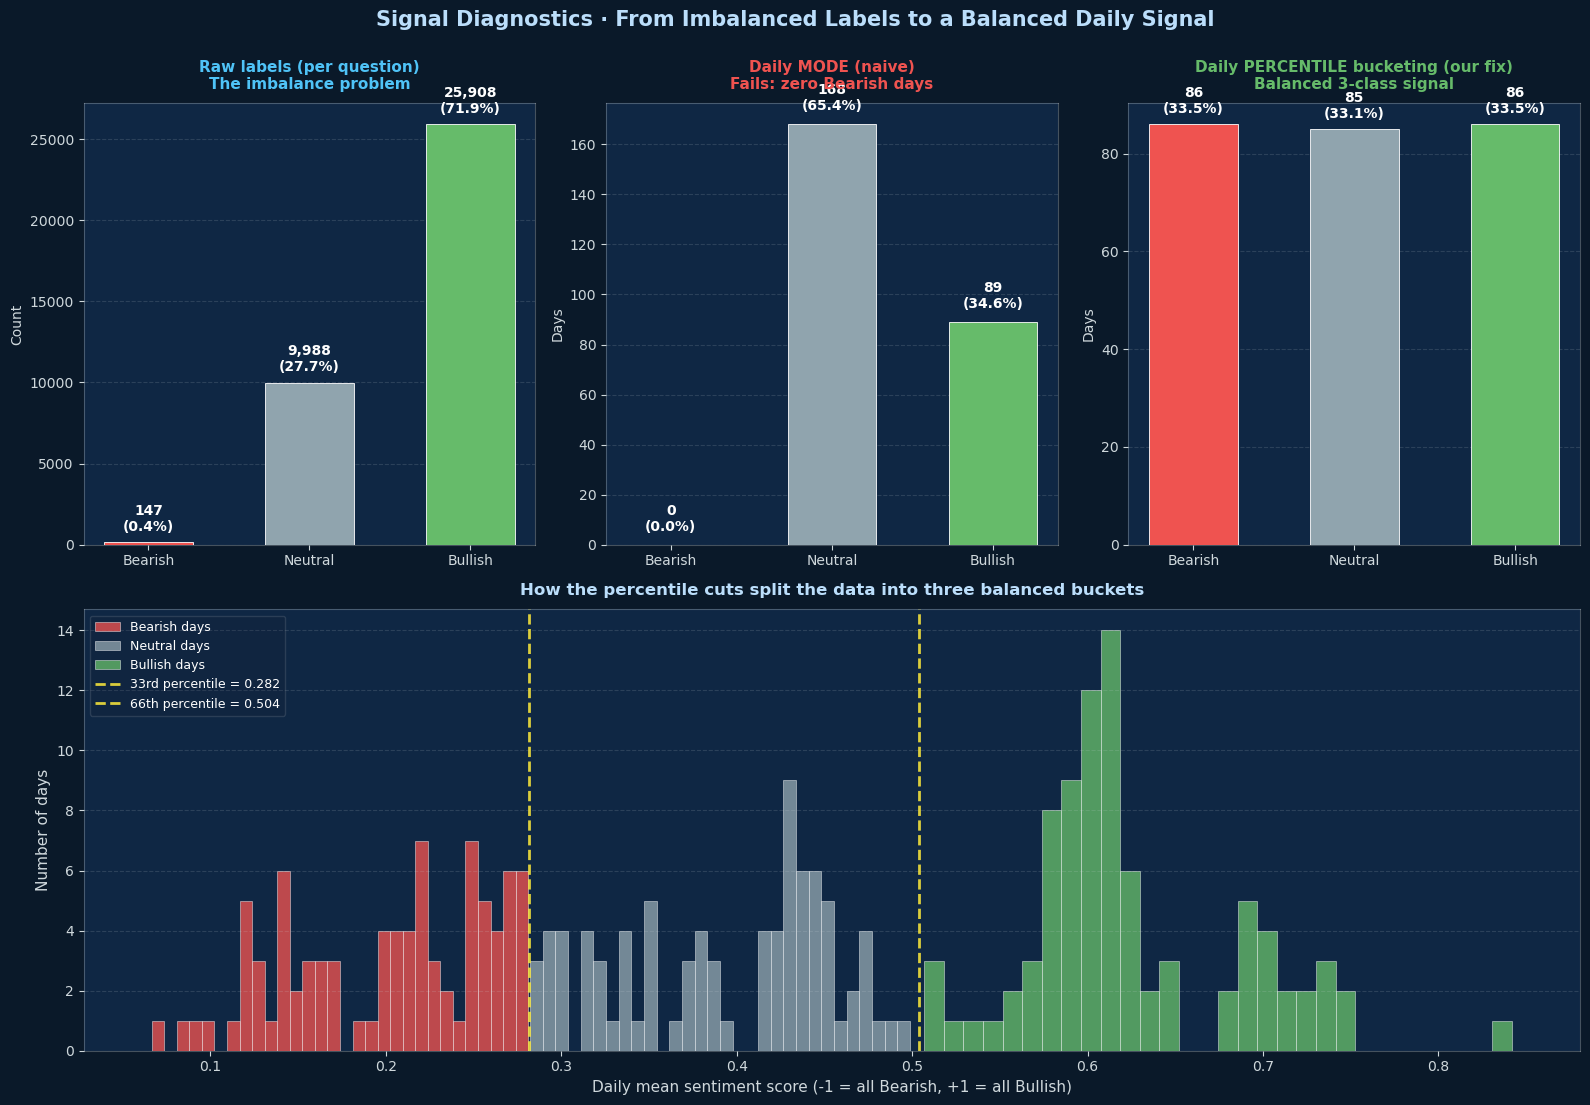

In [49]:
# ── Theme palette (blue/white) ─────────────────────────────────────────────
BG_DARK    = '#0a1929'
PANEL      = '#0f2744'
ACCENT     = '#4fc3f7'
ACCENT_2   = '#bbdefb'
TEXT       = '#ffffff'
TEXT_SOFT  = '#cfd8dc'

SENT_COLORS = {'Bearish': '#ef5350', 'Neutral': '#90a4ae', 'Bullish': '#66bb6a'}

# ── Diagnostic A: signal distributions before and after the fix ────────────
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor(BG_DARK)

ax1 = plt.subplot(2, 3, 1)
ax2 = plt.subplot(2, 3, 2)
ax3 = plt.subplot(2, 3, 3)

for ax in (ax1, ax2, ax3):
    ax.set_facecolor(PANEL)
    for s in ax.spines.values():
        s.set_color(TEXT_SOFT); s.set_alpha(0.3)
    ax.tick_params(colors=TEXT_SOFT)

# A1: raw labels (the imbalance problem)
raw_counts = classification_df['sentiment'].value_counts().reindex(['Bearish', 'Neutral', 'Bullish'])
bars = ax1.bar(raw_counts.index, raw_counts.values,
               color=[SENT_COLORS[c] for c in raw_counts.index],
               edgecolor='white', linewidth=0.6, width=0.55, zorder=3)
for bar, val in zip(bars, raw_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + max(raw_counts.values)*0.02,
             f'{val:,}\n({100*val/raw_counts.sum():.1f}%)',
             ha='center', va='bottom', color=TEXT, fontsize=10, fontweight='bold')
ax1.set_title('Raw labels (per question)\nThe imbalance problem',
              color=ACCENT, fontweight='bold', fontsize=11, pad=10)
ax1.set_ylabel('Count', color=TEXT_SOFT)
ax1.grid(axis='y', alpha=0.15, color=TEXT_SOFT)

# A2: daily mode (what would have happened)
def _mode(s): return s.value_counts().idxmax() if len(s) else None
mode_signal = (daily_sent_full.groupby('date')['sentiment'].agg(_mode))
mode_counts = mode_signal.value_counts().reindex(['Bearish', 'Neutral', 'Bullish']).fillna(0)
bars = ax2.bar(mode_counts.index, mode_counts.values,
               color=[SENT_COLORS[c] for c in mode_counts.index],
               edgecolor='white', linewidth=0.6, width=0.55, zorder=3)
for bar, val in zip(bars, mode_counts.values):
    pct = 100*val/mode_counts.sum() if mode_counts.sum() > 0 else 0
    ax2.text(bar.get_x() + bar.get_width()/2, val + max(mode_counts.values)*0.02 + 1,
             f'{int(val)}\n({pct:.1f}%)',
             ha='center', va='bottom', color=TEXT, fontsize=10, fontweight='bold')
ax2.set_title('Daily MODE (naive)\nFails: zero Bearish days',
              color='#ef5350', fontweight='bold', fontsize=11, pad=10)
ax2.set_ylabel('Days', color=TEXT_SOFT)
ax2.grid(axis='y', alpha=0.15, color=TEXT_SOFT)

# A3: daily percentile (our fix)
pct_counts = signal_df['signal'].value_counts().reindex(['Bearish', 'Neutral', 'Bullish'])
bars = ax3.bar(pct_counts.index, pct_counts.values,
               color=[SENT_COLORS[c] for c in pct_counts.index],
               edgecolor='white', linewidth=0.6, width=0.55, zorder=3)
for bar, val in zip(bars, pct_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, val + max(pct_counts.values)*0.02,
             f'{int(val)}\n({100*val/pct_counts.sum():.1f}%)',
             ha='center', va='bottom', color=TEXT, fontsize=10, fontweight='bold')
ax3.set_title('Daily PERCENTILE bucketing (our fix)\nBalanced 3-class signal',
              color='#66bb6a', fontweight='bold', fontsize=11, pad=10)
ax3.set_ylabel('Days', color=TEXT_SOFT)
ax3.grid(axis='y', alpha=0.15, color=TEXT_SOFT)

# A4: histogram of daily mean scores with quantile cuts
ax4 = plt.subplot(2, 1, 2)
ax4.set_facecolor(PANEL)
for s in ax4.spines.values():
    s.set_color(TEXT_SOFT); s.set_alpha(0.3)
ax4.tick_params(colors=TEXT_SOFT)

scores = daily_score['mean_score'].values
for label, color in SENT_COLORS.items():
    mask = signal_df['signal'].values == label
    ax4.hist(scores[mask], bins=30, color=color, alpha=0.78,
             edgecolor='white', linewidth=0.4, label=f'{label} days')

ax4.axvline(q33, color='#ffeb3b', linestyle='--', linewidth=2, alpha=0.85,
            label=f'33rd percentile = {q33:.3f}')
ax4.axvline(q66, color='#ffeb3b', linestyle='--', linewidth=2, alpha=0.85,
            label=f'66th percentile = {q66:.3f}')

ax4.set_xlabel('Daily mean sentiment score (-1 = all Bearish, +1 = all Bullish)',
               color=TEXT_SOFT, fontsize=11)
ax4.set_ylabel('Number of days', color=TEXT_SOFT, fontsize=11)
ax4.set_title('How the percentile cuts split the data into three balanced buckets',
              color=ACCENT_2, fontweight='bold', fontsize=12, pad=10)
ax4.legend(framealpha=0.15, labelcolor=TEXT, fontsize=9, loc='upper left')
ax4.grid(axis='y', alpha=0.15, color=TEXT_SOFT)

plt.suptitle('Signal Diagnostics · From Imbalanced Labels to a Balanced Daily Signal',
             color=ACCENT_2, fontsize=15, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig('plot_signal_diagnostic.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()


## 5.3 · The Signal Over Time

Before we run any strategy, it is worth looking at how the signal actually evolves through
time. Are the Bearish, Neutral, and Bullish days spread throughout the period, or are they
clustered into regimes? If everything Bearish happened in one short stretch, that would
be a red flag for the backtest.

This plot overlays the BTC price on top of the daily mean sentiment score, so we can see
visually whether the signal has any obvious relationship with what BTC was doing.


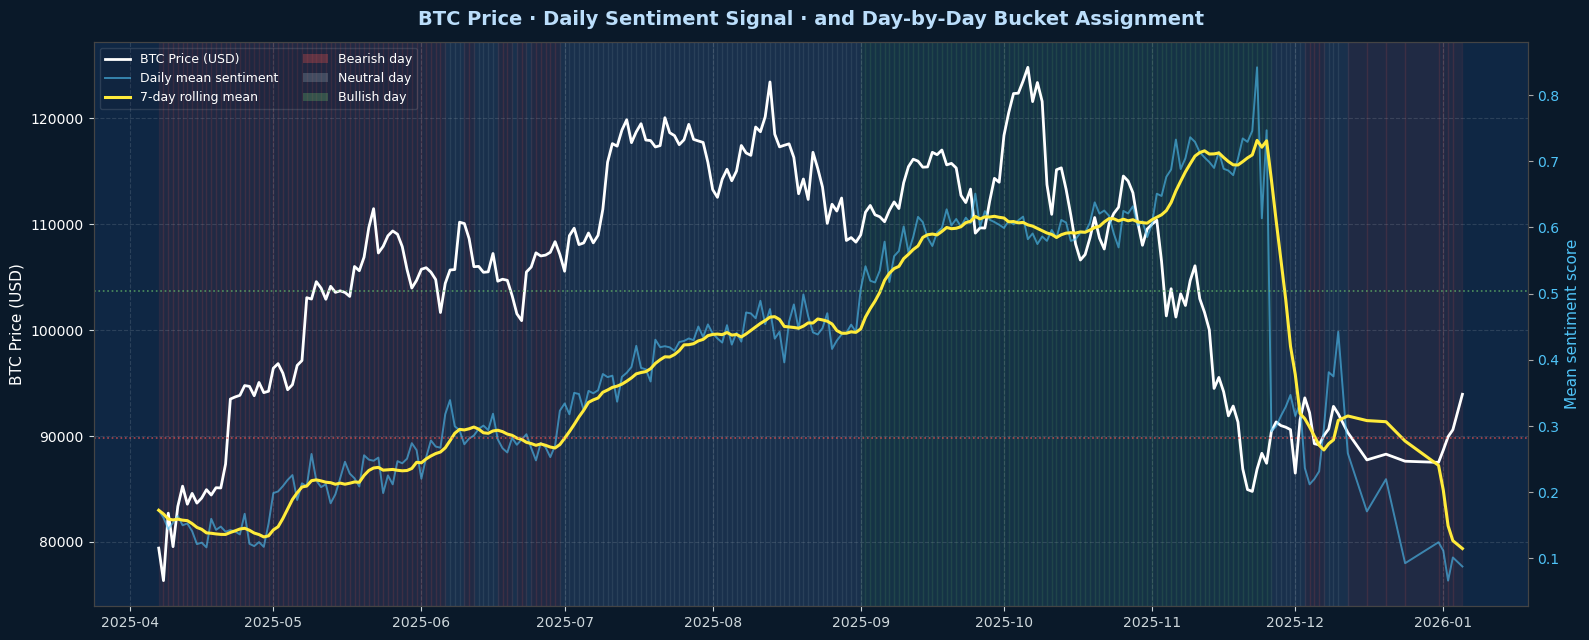

Saved plot_signal_over_time.png


In [50]:
# ── Plot: BTC price overlaid with daily sentiment score and bucket shading ──
fig, ax1 = plt.subplots(figsize=(16, 6.5))
fig.patch.set_facecolor(BG_DARK)
ax1.set_facecolor(PANEL)
for s in ax1.spines.values():
    s.set_color(TEXT_SOFT); s.set_alpha(0.3)
ax1.tick_params(colors=TEXT_SOFT)

# Merge BTC price onto signal
btc_for_overlay = btc_df[['PriceUSD']].reset_index()
btc_for_overlay['date'] = pd.to_datetime(btc_for_overlay['date'])
overlay = signal_df.merge(btc_for_overlay, on='date', how='inner').sort_values('date').reset_index(drop=True)

# Shade background by signal bucket
for i in range(len(overlay) - 1):
    sig = overlay.iloc[i]['signal']
    ax1.axvspan(overlay.iloc[i]['date'], overlay.iloc[i+1]['date'],
                color=SENT_COLORS[sig], alpha=0.08, zorder=0)

# BTC price line
ax1.plot(overlay['date'], overlay['PriceUSD'],
         color='#ffffff', linewidth=2.0, label='BTC Price (USD)', zorder=3)
ax1.set_ylabel('BTC Price (USD)', color=TEXT, fontsize=11)
ax1.tick_params(axis='y', labelcolor=TEXT)

# Right axis: daily mean sentiment score
ax2 = ax1.twinx()
ax2.plot(overlay['date'], overlay['mean_score'],
         color=ACCENT, linewidth=1.4, alpha=0.6, label='Daily mean sentiment')
# Rolling 7-day mean for smoothing
overlay_sorted = overlay.sort_values('date')
overlay_sorted['rolling'] = overlay_sorted['mean_score'].rolling(7, min_periods=1).mean()
ax2.plot(overlay_sorted['date'], overlay_sorted['rolling'],
         color='#ffeb3b', linewidth=2.2, label='7-day rolling mean')
ax2.axhline(q33, color='#ef5350', linestyle=':', linewidth=1.2, alpha=0.7)
ax2.axhline(q66, color='#66bb6a', linestyle=':', linewidth=1.2, alpha=0.7)
ax2.set_ylabel('Mean sentiment score', color=ACCENT, fontsize=11)
ax2.tick_params(axis='y', labelcolor=ACCENT)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
from matplotlib.patches import Patch
extra = [
    Patch(facecolor=SENT_COLORS['Bearish'], alpha=0.3, label='Bearish day'),
    Patch(facecolor=SENT_COLORS['Neutral'], alpha=0.3, label='Neutral day'),
    Patch(facecolor=SENT_COLORS['Bullish'], alpha=0.3, label='Bullish day'),
]
ax1.legend(lines1 + lines2 + extra, labels1 + labels2 + [p.get_label() for p in extra],
           loc='upper left', framealpha=0.15, labelcolor=TEXT, fontsize=9, ncol=2)

ax1.set_title('BTC Price · Daily Sentiment Signal · and Day-by-Day Bucket Assignment',
              color=ACCENT_2, fontweight='bold', fontsize=14, pad=12)
ax1.grid(True, alpha=0.15, color=TEXT_SOFT)

plt.tight_layout()
plt.savefig('plot_signal_over_time.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Saved plot_signal_over_time.png')


## 5.4 · What Were People Actually Asking About on Each Type of Day?

Before we backtest, one more diagnostic. We look at the actual question text on each type
of day. If the signal is real, we should see different topics dominating each bucket. If
all three word clouds look the same, our signal is probably noise.

This is also a sanity check for something more subtle: is the signal really about BTC
sentiment, or is it secretly tracking something else (politics, sports, news cycles)?
The word clouds will tell us.


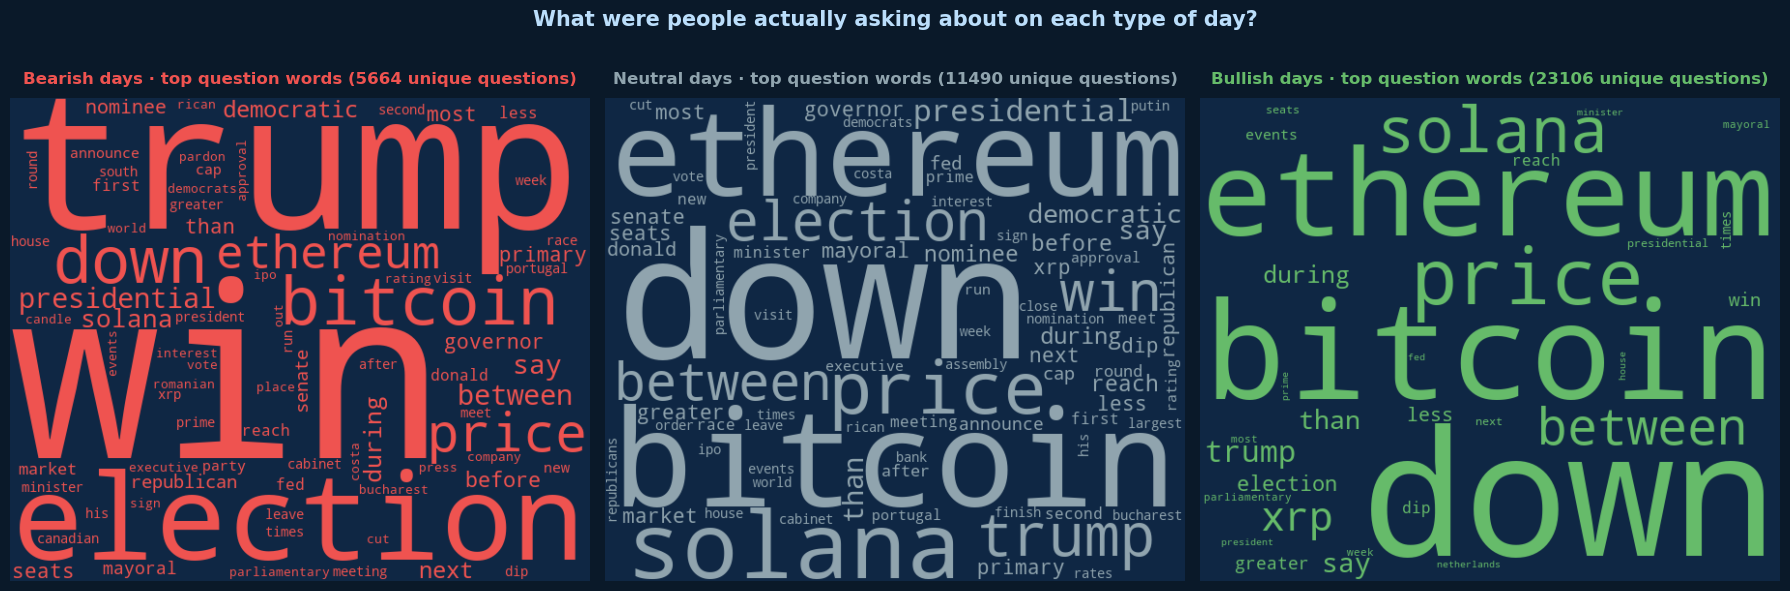


Top 10 most frequent words per signal class:

 Bearish (5664 questions):
    win                   1175
    trump                 1170
    election              1167
    bitcoin                892
    down                   853
    price                  851
    ethereum               626
    presidential           564
    between                563
    say                    516

 Neutral (11490 questions):
    down                  5481
    bitcoin               2995
    ethereum              2669
    solana                2219
    price                 1763
    trump                 1123
    win                   1014
    election               996
    between                922
    presidential           495

 Bullish (23106 questions):
    down                 13498
    bitcoin               7545
    ethereum              7516
    price                 7464
    solana                4812
    between               2768
    xrp                   1673
    trump                  805


In [51]:
# ── Word clouds per signal class ──────────────────────────────────────────
from wordcloud import WordCloud
from collections import Counter
import re

STOPWORDS = set('''
will be the a an of in on to for and or with by from is are was were
this that these those at as it its be can has had have not but if then
year years month months day days time when how what who which percent above below
2024 2025 2026 january february march april may june july august september october november december
'''.split())

# Gather all questions traded on each class of day
class_questions = {}
for cls in ['Bearish', 'Neutral', 'Bullish']:
    cls_dates = set(signal_df[signal_df['signal'] == cls]['date'])
    qs = daily_sent_full[daily_sent_full['date'].isin(cls_dates)]['question'].unique()
    class_questions[cls] = qs

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG_DARK)

for ax, cls in zip(axes, ['Bearish', 'Neutral', 'Bullish']):
    ax.set_facecolor(PANEL)

    text = ' '.join(class_questions[cls]).lower()
    words = re.findall(r"\b[a-z]{3,}\b", text)
    words = [w for w in words if w not in STOPWORDS]
    freq  = Counter(words).most_common(120)
    freq_dict = dict(freq) if freq else {'(no data)': 1}

    base_color = SENT_COLORS[cls]
    def make_color_func(c):
        def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
            return c
        return color_func

    wc = WordCloud(width=600, height=500, background_color=PANEL,
                   color_func=make_color_func(base_color),
                   max_words=80, prefer_horizontal=0.9,
                   min_font_size=10, relative_scaling=0.5).generate_from_frequencies(freq_dict)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{cls} days · top question words ({len(class_questions[cls])} unique questions)',
                 color=base_color, fontweight='bold', fontsize=12, pad=10)
    ax.axis('off')

plt.suptitle('What were people actually asking about on each type of day?',
             color=ACCENT_2, fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_wordclouds_by_signal.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

# Top 10 distinctive words per class
print('\nTop 10 most frequent words per signal class:')
print('=' * 70)
for cls in ['Bearish', 'Neutral', 'Bullish']:
    text = ' '.join(class_questions[cls]).lower()
    words = re.findall(r"\b[a-z]{3,}\b", text)
    words = [w for w in words if w not in STOPWORDS]
    top10 = Counter(words).most_common(10)
    print(f'\n{cls:>8} ({len(class_questions[cls])} questions):')
    for w, c in top10:
        print(f'    {w:<20} {c:>5}')


## 5.5 · Defining the Three Strategies

Now we have a balanced daily signal. Next we define the actual strategies we will test.
All three spend the same average daily budget so the comparison is apples to apples.

| Strategy | Bearish day | Neutral day | Bullish day | What it bets on |
|----------|-------------|-------------|-------------|-----------------|
| **Baseline DCA** | $100 | $100 | $100 | Nothing, just buys flat |
| **Naive (follow labels)** | $50 | $100 | $150 | The labels mean what they say |
| **Contrarian** | $150 | $100 | $50 | The labels are inverted (Phase 2.4) |

The multipliers `0.5×` and `1.5×` are picked by hand, not learned. That is deliberate.
A learned multiplier would over-fit the in-sample period. A fixed pair of round numbers
is something a reader can interpret immediately: "buy half as much" or "buy 50% more".

**Neutral always equals the baseline** in every strategy. This is David's interpretation:
when the model is not confident either way, do not use the Polymarket signal at all.
The Neutral bucket is doing real work here as a "do nothing" gate.

The Bullish and Bearish multipliers also cancel out by construction (0.5 + 1.5 = 2.0 = two
baselines), so over a balanced sample period the total dollars spent is roughly the same
across all three strategies. This is what makes the comparison fair.

In [ ]:
# ── Strategy definitions ──────────────────────────────────────────────────
DAILY_BUDGET = 100.0  # USD per day baseline

# Multiplier per sentiment class. Neutral always = 1.0 (fall back to baseline).
STRATEGIES = {
    'Baseline DCA'   : {'Bearish': 1.0, 'Neutral': 1.0, 'Bullish': 1.0},
    'Naive (follow)' : {'Bearish': 0.5, 'Neutral': 1.0, 'Bullish': 1.5},
    'Contrarian'     : {'Bearish': 1.5, 'Neutral': 1.0, 'Bullish': 0.5},
}

print('Strategy multipliers:')
for name, mults in STRATEGIES.items():
    print(f'  {name:<18} Bearish×{mults["Bearish"]}  Neutral×{mults["Neutral"]}  Bullish×{mults["Bullish"]}')

print(f'\nDaily budget baseline: ${DAILY_BUDGET:.2f}')
print('The Bullish and Bearish multipliers cancel out on average so all strategies')
print('spend roughly the same total over the full period.')

Strategy multipliers:
  Baseline DCA       Bearish×1.0  Neutral×1.0  Bullish×1.0
  Naive (follow)     Bearish×0.5  Neutral×1.0  Bullish×1.5
  Contrarian         Bearish×1.5  Neutral×1.0  Bullish×0.5

Daily budget baseline: $100.00
The Bullish and Bearish multipliers cancel out on average so all strategies
spend roughly the same total over the full period.


## 5.6 · Running the In-Sample Backtest

The backtest is mechanically simple. For each day in the signal window:

1. Look up that day's signal class (Bearish, Neutral, or Bullish).
2. Multiply the daily budget by the strategy's multiplier for that class to get the day's spend.
3. Buy BTC at that day's close price with the day's spend.
4. Track running totals: cumulative USD spent, cumulative BTC acquired, and the running
   average cost basis (total USD / total BTC).

The key metric is the **average cost basis at the end of the window**. A lower average cost
basis means the strategy timed its buys better on average. We compare both alternatives
against the Baseline DCA as the benchmark.

First a small safety check on `btc_df` because in earlier cells we may have left it as a
polars DataFrame, which does not have the pandas methods we need.

In [52]:
# ── Safety check: make sure btc_df is a pandas DataFrame with a date index ──
print('type of btc_df       :', type(btc_df))
print('has reset_index?     :', hasattr(btc_df, 'reset_index'))

# If it is polars, convert it
if 'polars' in str(type(btc_df)):
    print('\nConverting polars → pandas...')
    btc_df = btc_df.to_pandas()
    btc_df['date'] = pd.to_datetime(btc_df['time']) if 'time' in btc_df.columns else pd.to_datetime(btc_df['date'])
    btc_df['btc_return'] = btc_df['PriceUSD'].pct_change()
    btc_df['date'] = btc_df['date'].dt.normalize()
    btc_df = btc_df.set_index('date')

print('Final btc_df type:', type(btc_df))
print('Index range      :', btc_df.index.min(), '→', btc_df.index.max())

type of btc_df       : <class 'pandas.core.frame.DataFrame'>
has reset_index?     : True
Final btc_df type: <class 'pandas.core.frame.DataFrame'>
Index range      : 2009-01-03 00:00:00 → 2026-01-14 00:00:00


In [53]:
# ── Merge signal with BTC price and run the backtest ───────────────────────
btc_for_bt = btc_df[['PriceUSD']].reset_index()
btc_for_bt['date'] = pd.to_datetime(btc_for_bt['date'])

bt = signal_df.merge(btc_for_bt, on='date', how='inner').sort_values('date').reset_index(drop=True)
bt = bt.dropna(subset=['PriceUSD'])
print(f'Backtest window: {bt["date"].min().date()} to {bt["date"].max().date()}  ({len(bt)} days)')

def run_strategy(bt_df, multipliers, daily_budget=DAILY_BUDGET):
    spends     = bt_df['signal'].map(multipliers).values * daily_budget
    prices     = bt_df['PriceUSD'].values
    btc_bought = spends / prices

    out = bt_df[['date', 'signal', 'PriceUSD']].copy()
    out['usd_spent']  = spends
    out['btc_bought'] = btc_bought
    out['cum_usd']    = spends.cumsum()
    out['cum_btc']    = btc_bought.cumsum()
    out['avg_cost']   = out['cum_usd'] / out['cum_btc']
    return out

results = {name: run_strategy(bt, mults) for name, mults in STRATEGIES.items()}

# ── Build summary table ────────────────────────────────────────────────────
summary = []
for name, r in results.items():
    final = r.iloc[-1]
    summary.append({
        'Strategy'           : name,
        'Total USD spent'    : final['cum_usd'],
        'Total BTC acquired' : final['cum_btc'],
        'Avg cost basis'     : final['avg_cost'],
        'Final BTC value'    : final['cum_btc'] * final['PriceUSD'],
        'P&L (USD)'          : final['cum_btc'] * final['PriceUSD'] - final['cum_usd'],
        'Return (%)'         : 100 * (final['cum_btc'] * final['PriceUSD'] / final['cum_usd'] - 1),
    })

summary_df = pd.DataFrame(summary)
print('\nIn-sample backtest results:')
print('=' * 100)
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))
print('=' * 100)

# ── Compare vs baseline ────────────────────────────────────────────────────
baseline_cost = summary_df[summary_df['Strategy'] == 'Baseline DCA']['Avg cost basis'].values[0]
print(f'\nBaseline DCA avg cost basis: ${baseline_cost:,.2f}')
for name in ['Naive (follow)', 'Contrarian']:
    cost = summary_df[summary_df['Strategy'] == name]['Avg cost basis'].values[0]
    diff = cost - baseline_cost
    pct  = 100 * diff / baseline_cost
    verdict = 'better (lower)' if diff < 0 else 'worse (higher)'
    print(f'  {name:<18} avg cost: ${cost:,.2f}  →  {pct:+.2f}% vs baseline ({verdict})')


Backtest window: 2025-04-07 to 2026-01-05  (257 days)

In-sample backtest results:
      Strategy  Total USD spent  Total BTC acquired  Avg cost basis  Final BTC value  P&L (USD)  Return (%)
  Baseline DCA        25,700.00                0.25      104,451.46        23,115.79  -2,584.21      -10.06
Naive (follow)        25,700.00                0.24      106,500.70        22,671.01  -3,028.99      -11.79
    Contrarian        25,700.00                0.25      102,479.60        23,560.58  -2,139.42       -8.32

Baseline DCA avg cost basis: $104,451.46
  Naive (follow)     avg cost: $106,500.70  →  +1.96% vs baseline (worse (higher))
  Contrarian         avg cost: $102,479.60  →  -1.89% vs baseline (better (lower))


## 5.7 · Visual Summary of the Backtest Results

The table above is the most important set of numbers in the whole notebook, so we also
show it visually. Three small panels:

* **Average cost basis** per strategy. Lower is better. The benchmark is shown as a
  dashed line for reference.
* **Total BTC acquired** per strategy. Higher is better, holding total spend constant.
* **Final return percent**. This depends on the BTC price at the end of the window so
  it can be negative if BTC dropped overall.


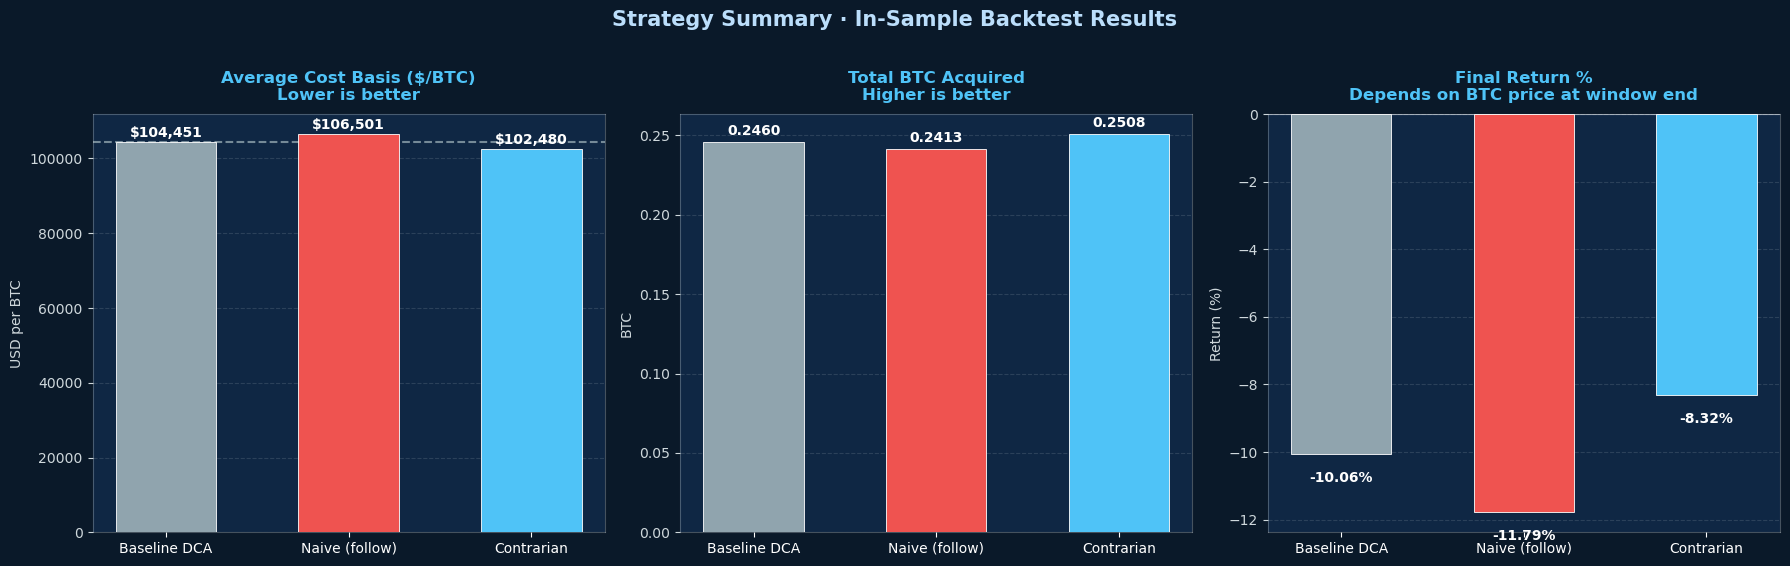

Saved plot_strategy_summary.png


In [54]:
# ── Summary visual ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.patch.set_facecolor(BG_DARK)

STRAT_COLORS = {
    'Baseline DCA'   : '#90a4ae',
    'Naive (follow)' : '#ef5350',
    'Contrarian'     : '#4fc3f7',
}

for ax in axes:
    ax.set_facecolor(PANEL)
    for s in ax.spines.values():
        s.set_color(TEXT_SOFT); s.set_alpha(0.3)
    ax.tick_params(colors=TEXT_SOFT)

names  = summary_df['Strategy'].tolist()
colors = [STRAT_COLORS[n] for n in names]

# Panel 1: avg cost basis
bars = axes[0].bar(names, summary_df['Avg cost basis'], color=colors,
                   edgecolor='white', linewidth=0.6, width=0.55, zorder=3)
axes[0].axhline(baseline_cost, color='#90a4ae', linestyle='--', linewidth=1.5, alpha=0.8)
for bar, val in zip(bars, summary_df['Avg cost basis']):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + max(summary_df['Avg cost basis'])*0.005,
                 f'${val:,.0f}', ha='center', va='bottom', color=TEXT,
                 fontsize=10, fontweight='bold')
axes[0].set_title('Average Cost Basis ($/BTC)\nLower is better',
                  color=ACCENT, fontweight='bold', fontsize=12, pad=10)
axes[0].set_ylabel('USD per BTC', color=TEXT_SOFT)
axes[0].grid(axis='y', alpha=0.15, color=TEXT_SOFT)
axes[0].tick_params(axis='x', colors=TEXT)

# Panel 2: total BTC acquired
bars = axes[1].bar(names, summary_df['Total BTC acquired'], color=colors,
                   edgecolor='white', linewidth=0.6, width=0.55, zorder=3)
for bar, val in zip(bars, summary_df['Total BTC acquired']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + max(summary_df['Total BTC acquired'])*0.01,
                 f'{val:.4f}', ha='center', va='bottom', color=TEXT,
                 fontsize=10, fontweight='bold')
axes[1].set_title('Total BTC Acquired\nHigher is better',
                  color=ACCENT, fontweight='bold', fontsize=12, pad=10)
axes[1].set_ylabel('BTC', color=TEXT_SOFT)
axes[1].grid(axis='y', alpha=0.15, color=TEXT_SOFT)
axes[1].tick_params(axis='x', colors=TEXT)

# Panel 3: return %
bars = axes[2].bar(names, summary_df['Return (%)'], color=colors,
                   edgecolor='white', linewidth=0.6, width=0.55, zorder=3)
axes[2].axhline(0, color='white', linewidth=0.8, alpha=0.5)
for bar, val in zip(bars, summary_df['Return (%)']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 val + (0.3 if val >= 0 else -0.5),
                 f'{val:+.2f}%', ha='center',
                 va='bottom' if val >= 0 else 'top',
                 color=TEXT, fontsize=10, fontweight='bold')
axes[2].set_title('Final Return %\nDepends on BTC price at window end',
                  color=ACCENT, fontweight='bold', fontsize=12, pad=10)
axes[2].set_ylabel('Return (%)', color=TEXT_SOFT)
axes[2].grid(axis='y', alpha=0.15, color=TEXT_SOFT)
axes[2].tick_params(axis='x', colors=TEXT)

plt.suptitle('Strategy Summary · In-Sample Backtest Results',
             color=ACCENT_2, fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_strategy_summary.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Saved plot_strategy_summary.png')


## 5.8 · Equity Curves Through Time

The summary table tells us where each strategy ended up, but not how it got there. The
equity curves show the running totals across every single day of the backtest window.
Two panels:

* **Cumulative BTC accumulated.** The y-axis is BTC, the x-axis is time. A higher line at
  the right end means more BTC for the same total spend.
* **Running average cost basis.** The y-axis is dollars per BTC. A lower line at the right
  end means the strategy bought cheaper on average.

If the Contrarian line stays consistently below the Baseline line throughout the window
(not just at the end), that is much stronger evidence than a single end-point comparison.

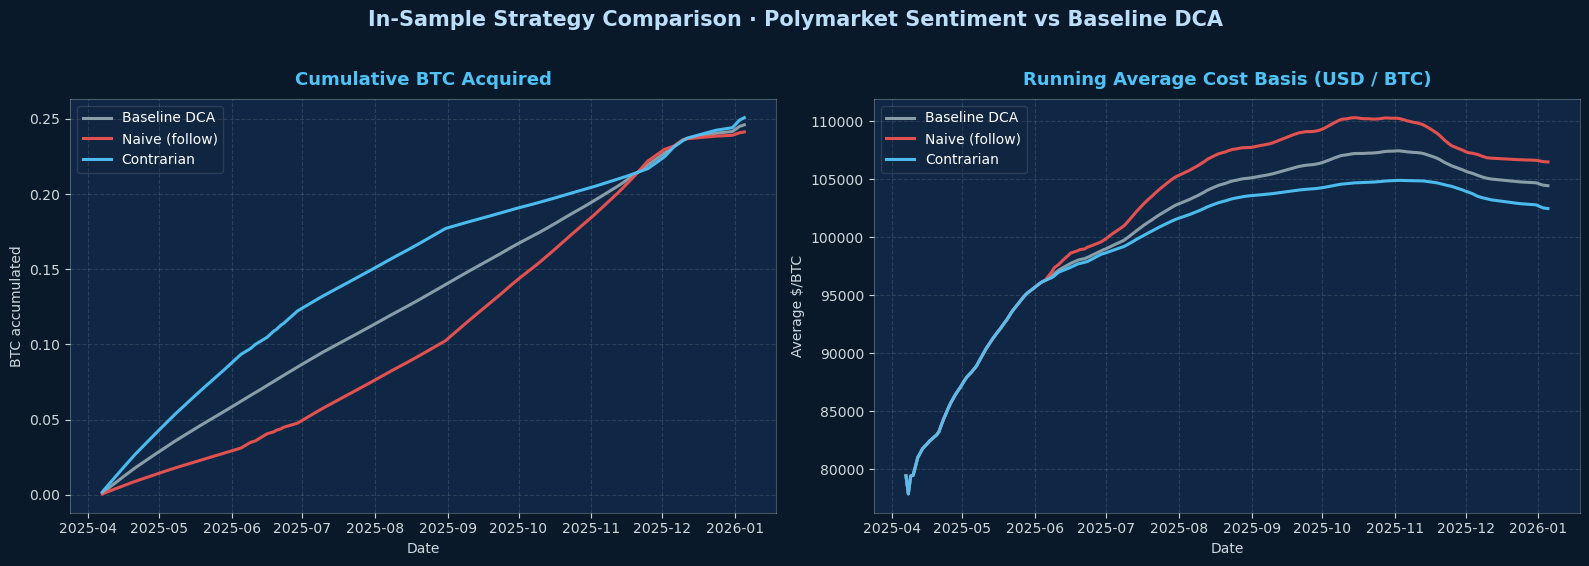

Saved plot_strategy_curves.png


In [55]:
# ── Equity curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor(BG_DARK)
for ax in axes:
    ax.set_facecolor(PANEL)
    for s in ax.spines.values():
        s.set_color(TEXT_SOFT); s.set_alpha(0.3)
    ax.tick_params(colors=TEXT_SOFT)

# Left: cumulative BTC
for name, r in results.items():
    axes[0].plot(r['date'], r['cum_btc'], color=STRAT_COLORS[name],
                 linewidth=2.2, label=name, alpha=0.95)
axes[0].set_title('Cumulative BTC Acquired', color=ACCENT, fontweight='bold', fontsize=13, pad=10)
axes[0].set_xlabel('Date', color=TEXT_SOFT)
axes[0].set_ylabel('BTC accumulated', color=TEXT_SOFT)
axes[0].legend(framealpha=0.15, labelcolor=TEXT, fontsize=10, loc='upper left')
axes[0].grid(True, alpha=0.15, color=TEXT_SOFT)

# Right: running avg cost basis
for name, r in results.items():
    axes[1].plot(r['date'], r['avg_cost'], color=STRAT_COLORS[name],
                 linewidth=2.2, label=name, alpha=0.95)
axes[1].set_title('Running Average Cost Basis (USD / BTC)', color=ACCENT, fontweight='bold', fontsize=13, pad=10)
axes[1].set_xlabel('Date', color=TEXT_SOFT)
axes[1].set_ylabel('Average $/BTC', color=TEXT_SOFT)
axes[1].legend(framealpha=0.15, labelcolor=TEXT, fontsize=10, loc='upper left')
axes[1].grid(True, alpha=0.15, color=TEXT_SOFT)

plt.suptitle('In-Sample Strategy Comparison · Polymarket Sentiment vs Baseline DCA',
             color=ACCENT_2, fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_strategy_curves.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Saved plot_strategy_curves.png')


## 5.9 · Sample Paths · Watching the Strategy React in Real Time

This is the visualisation David specifically asked for. The aggregate numbers are
convincing in one sense, but they hide what is happening day to day. By zooming into a few
windows and plotting the BTC price together with the daily sentiment shading and the
actual contrarian buy bars, the reader can see for themselves that:

1. The strategy is genuinely reacting to the signal day by day.
2. The buy size is being modulated in a sensible way (bigger on Bearish days, smaller on
   Bullish days for the Contrarian version).
3. Each window has its own mini-cost-basis comparison printed in the corner, so we are
   not relying on the full aggregate to make the case.

If the Contrarian rule beats the baseline in each window individually, not just on average
across the whole period, that is independent evidence the result is not driven by one
lucky stretch.

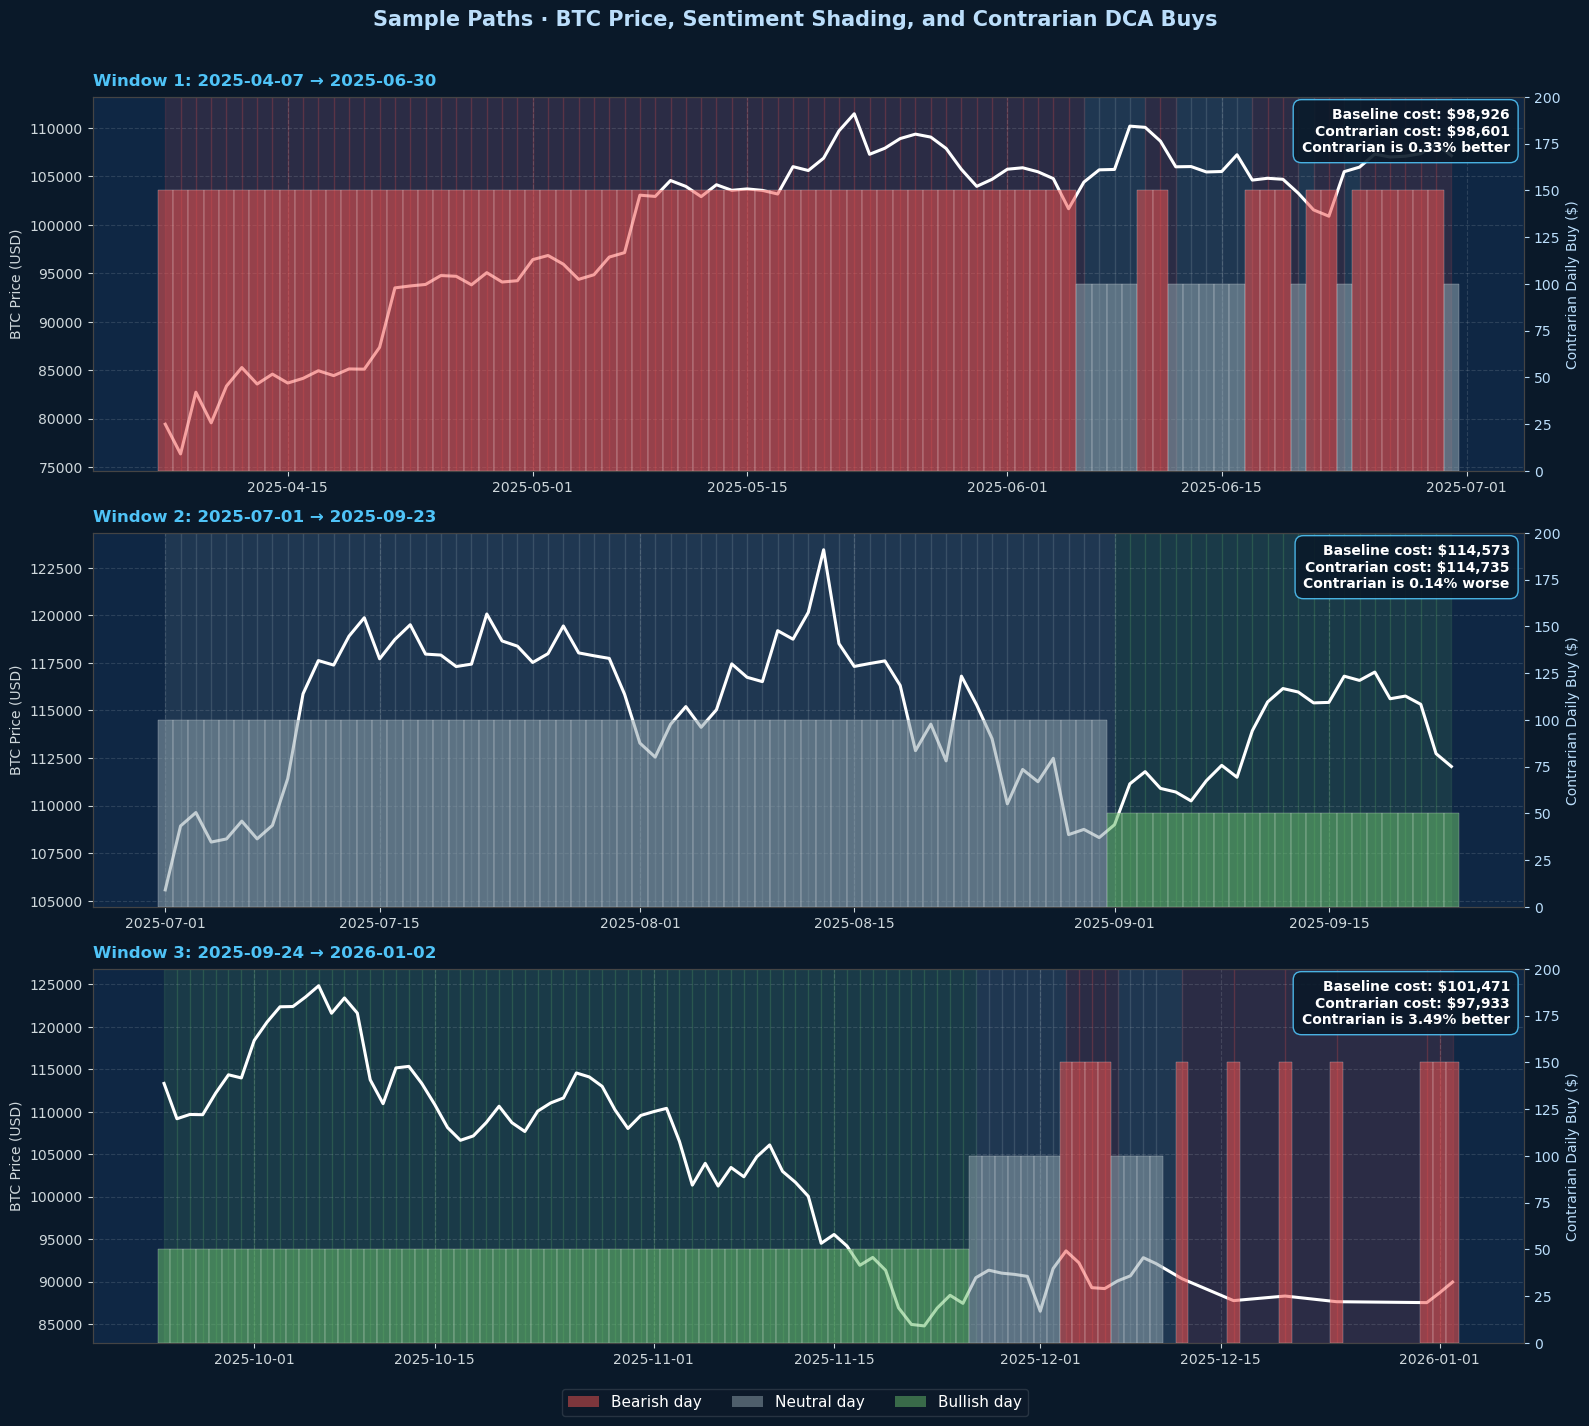

Saved plot_sample_paths.png


In [56]:
# ── Three sample windows ──────────────────────────────────────────────────
n_days = len(bt)
third  = n_days // 3
window_len = min(90, third)

windows = []
for i in range(3):
    start = i * third + (third - window_len) // 2
    end   = start + window_len
    windows.append((bt.iloc[start:end].reset_index(drop=True),
                    f'Window {i+1}: {bt.iloc[start]["date"].date()} → {bt.iloc[end-1]["date"].date()}'))

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.patch.set_facecolor(BG_DARK)

contrarian_full = results['Contrarian']

for ax, (win_df, title) in zip(axes, windows):
    ax.set_facecolor(PANEL)
    for s in ax.spines.values():
        s.set_color(TEXT_SOFT); s.set_alpha(0.3)
    ax.tick_params(colors=TEXT_SOFT)

    # Shade sentiment background
    for i in range(len(win_df) - 1):
        sent = win_df.iloc[i]['signal']
        ax.axvspan(win_df.iloc[i]['date'], win_df.iloc[i+1]['date'],
                   color=SENT_COLORS[sent], alpha=0.13, zorder=0)

    # BTC price line
    ax.plot(win_df['date'], win_df['PriceUSD'],
            color='#ffffff', linewidth=2.2, label='BTC Price', zorder=3)
    ax.set_ylabel('BTC Price (USD)', color=TEXT_SOFT)
    ax.set_title(title, color=ACCENT, fontweight='bold', fontsize=12, pad=8, loc='left')
    ax.grid(True, alpha=0.15, color=TEXT_SOFT)

    # Twin axis: contrarian daily buy size as bars
    ax2 = ax.twinx()
    buys_in_window = contrarian_full.merge(win_df[['date']], on='date', how='inner')
    bar_colors = [SENT_COLORS[s] for s in buys_in_window['signal']]
    ax2.bar(buys_in_window['date'], buys_in_window['usd_spent'],
            color=bar_colors, alpha=0.55, width=1.0, zorder=2,
            edgecolor='white', linewidth=0.3)
    ax2.set_ylabel('Contrarian Daily Buy ($)', color=ACCENT_2)
    ax2.tick_params(colors=ACCENT_2)
    ax2.set_ylim(0, DAILY_BUDGET * 2)

    # Per-window cost basis comparison
    win_baseline   = run_strategy(win_df, STRATEGIES['Baseline DCA'])
    win_contrarian = run_strategy(win_df, STRATEGIES['Contrarian'])
    cb_base = win_baseline.iloc[-1]['avg_cost']
    cb_cont = win_contrarian.iloc[-1]['avg_cost']
    pct_diff = 100 * (cb_cont - cb_base) / cb_base
    verdict = 'better' if pct_diff < 0 else 'worse'
    ax.text(0.99, 0.97,
            f'Baseline cost: ${cb_base:,.0f}\nContrarian cost: ${cb_cont:,.0f}\nContrarian is {abs(pct_diff):.2f}% {verdict}',
            transform=ax.transAxes, ha='right', va='top',
            color=TEXT, fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.6', facecolor=BG_DARK,
                      edgecolor=ACCENT, alpha=0.9))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=SENT_COLORS['Bearish'], alpha=0.5, label='Bearish day'),
    Patch(facecolor=SENT_COLORS['Neutral'], alpha=0.5, label='Neutral day'),
    Patch(facecolor=SENT_COLORS['Bullish'], alpha=0.5, label='Bullish day'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.01), framealpha=0.15,
           labelcolor=TEXT, fontsize=11)

plt.suptitle('Sample Paths · BTC Price, Sentiment Shading, and Contrarian DCA Buys',
             color=ACCENT_2, fontsize=15, fontweight='bold', y=1.0)
plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.savefig('plot_sample_paths.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Saved plot_sample_paths.png')

## 5.10 · Sensitivity Check · Does the Result Depend on the Exact Multipliers?

David asked us to keep the rule humanly interpretable and to avoid overfitting. One way
to check for overfitting is to vary the strength of the multiplier and see whether the
result is robust or whether we happened to pick the one value that worked.

We sweep the multiplier strength `s` from 0.1 (very mild rule) to 0.9 (very aggressive
rule). For each strength `s`, the rule is:

* Bullish day spends `(1 - s) × budget` (contrarian) or `(1 + s) × budget` (naive)
* Bearish day spends `(1 + s) × budget` (contrarian) or `(1 - s) × budget` (naive)
* Neutral day always spends `budget`

If the Contrarian line stays consistently below the baseline for the whole range of `s`,
we know the win is not knife-edge dependent on the exact `0.5` and `1.5` we picked.
This is arguably the most important plot in the entire Phase 5 section, because it is the
strongest test of whether the result is real or cherry-picked.

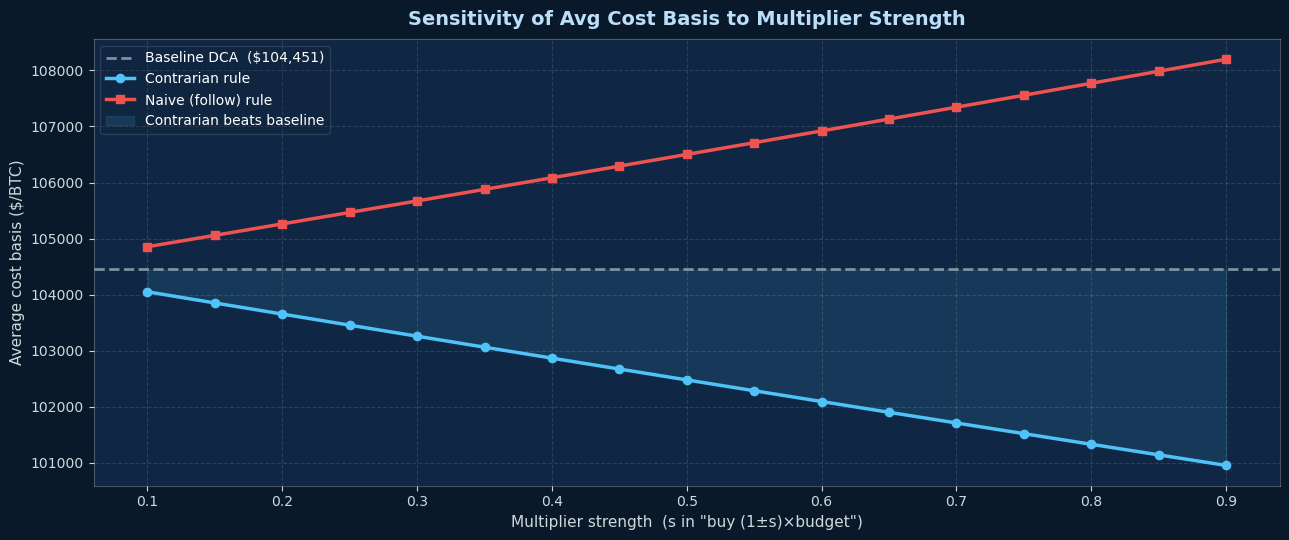

Saved plot_sensitivity.png

Contrarian beats baseline in 17/17 strength settings tested.
Naive  beats baseline in 0/17 settings.


In [57]:
# ── Sensitivity sweep over multiplier strength ─────────────────────────────
strengths = np.arange(0.1, 0.95, 0.05)
naive_costs   = []
contra_costs  = []
baseline_cost_final = results['Baseline DCA'].iloc[-1]['avg_cost']

for s in strengths:
    naive_m   = {'Bearish': 1.0 - s, 'Neutral': 1.0, 'Bullish': 1.0 + s}
    contra_m  = {'Bearish': 1.0 + s, 'Neutral': 1.0, 'Bullish': 1.0 - s}
    naive_costs.append(run_strategy(bt, naive_m).iloc[-1]['avg_cost'])
    contra_costs.append(run_strategy(bt, contra_m).iloc[-1]['avg_cost'])

naive_costs  = np.array(naive_costs)
contra_costs = np.array(contra_costs)

fig, ax = plt.subplots(figsize=(13, 5.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(PANEL)
for s in ax.spines.values():
    s.set_color(TEXT_SOFT); s.set_alpha(0.3)
ax.tick_params(colors=TEXT_SOFT)

ax.axhline(baseline_cost_final, color='#90a4ae', linestyle='--', linewidth=2,
           label=f'Baseline DCA  (${baseline_cost_final:,.0f})', alpha=0.85)
ax.plot(strengths, contra_costs, color=ACCENT, linewidth=2.5, marker='o',
        markersize=6, label='Contrarian rule')
ax.plot(strengths, naive_costs,  color='#ef5350', linewidth=2.5, marker='s',
        markersize=6, label='Naive (follow) rule')

ax.fill_between(strengths, baseline_cost_final, contra_costs,
                where=(contra_costs < baseline_cost_final),
                color=ACCENT, alpha=0.12, label='Contrarian beats baseline')

ax.set_xlabel('Multiplier strength  (s in "buy (1±s)×budget")', color=TEXT_SOFT, fontsize=11)
ax.set_ylabel('Average cost basis ($/BTC)', color=TEXT_SOFT, fontsize=11)
ax.set_title('Sensitivity of Avg Cost Basis to Multiplier Strength',
             color=ACCENT_2, fontweight='bold', fontsize=14, pad=10)
ax.legend(framealpha=0.15, labelcolor=TEXT, fontsize=10, loc='best')
ax.grid(True, alpha=0.15, color=TEXT_SOFT)

plt.tight_layout()
plt.savefig('plot_sensitivity.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Saved plot_sensitivity.png')

n_contra_beats = (contra_costs < baseline_cost_final).sum()
print(f'\nContrarian beats baseline in {n_contra_beats}/{len(strengths)} strength settings tested.')
print(f'Naive  beats baseline in {(naive_costs < baseline_cost_final).sum()}/{len(strengths)} settings.')

## 5.11 · Validating the Strategy Logic · BTC Returns by Signal Class

One more sanity check. If the contrarian story is correct, we should see this directly in
the data: on days the signal said Bearish, the next-day BTC return should on average be
*positive* (the market was overcrowded short, so it bounced). On days the signal said
Bullish, the next-day BTC return should on average be *negative* (the market was
overcrowded long, so it pulled back). Neutral should sit somewhere in between, ideally
close to zero.

This is a more direct test of the strategy's underlying logic than the backtest itself.
If this plot does not show the inverted pattern, the strategy result is probably a
coincidence. If it does show the inverted pattern, the strategy result is consistent with
a real effect in the underlying data.


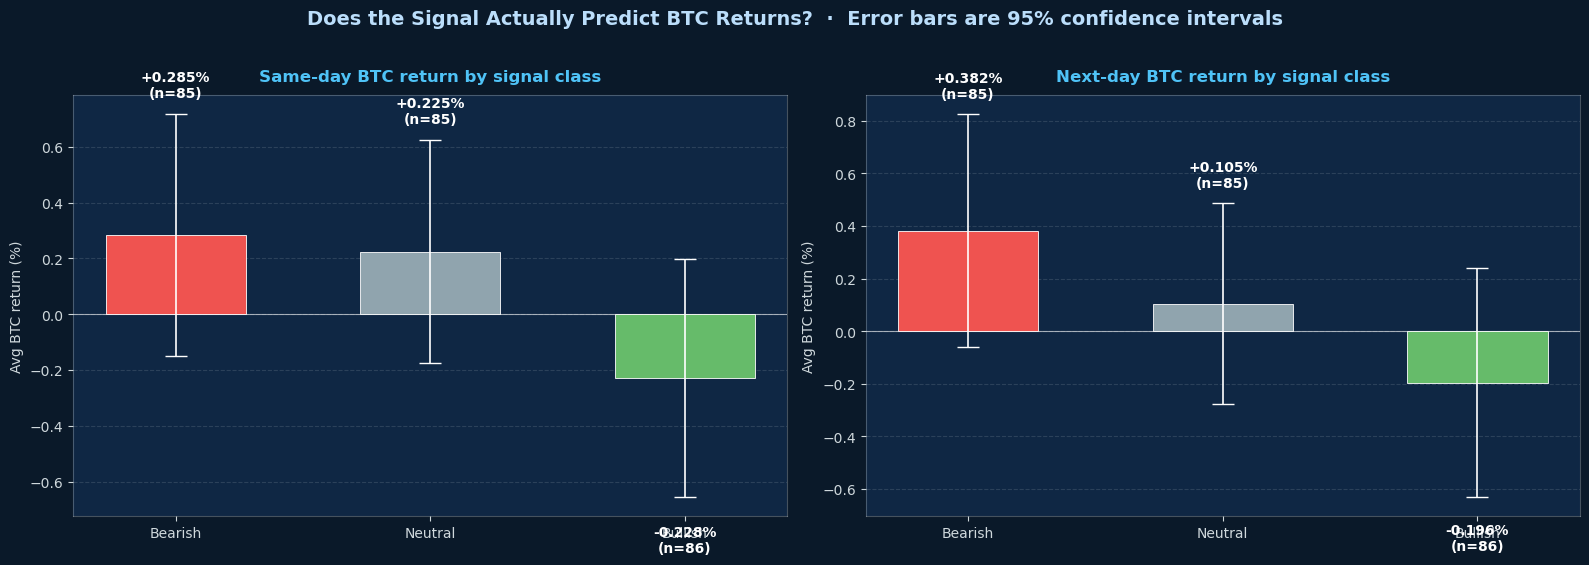

Saved plot_returns_by_signal.png

Same-day returns:
           mean  count  mean_pct
signal                          
Bearish  0.0028     85    0.2848
Neutral  0.0022     85    0.2247
Bullish -0.0023     86   -0.2283

Next-day returns:
           mean  count  mean_pct
signal                          
Bearish  0.0038     85    0.3821
Neutral  0.0011     85    0.1053
Bullish -0.0020     86   -0.1955


In [58]:
# ── Average BTC return by signal class (with confidence intervals) ─────────
btc_ret = btc_df[['btc_return']].reset_index()
btc_ret['date'] = pd.to_datetime(btc_ret['date'])

sig_ret = signal_df.merge(btc_ret, on='date', how='inner').dropna(subset=['btc_return'])

# Shift returns by one day so we test predictive (next-day) returns
sig_ret = sig_ret.sort_values('date').reset_index(drop=True)
sig_ret['next_day_return'] = sig_ret['btc_return'].shift(-1)
sig_ret = sig_ret.dropna(subset=['next_day_return'])

# Same-day returns (for comparison)
stats_same = sig_ret.groupby('signal')['btc_return'].agg(['mean', 'std', 'count'])
stats_next = sig_ret.groupby('signal')['next_day_return'].agg(['mean', 'std', 'count'])

stats_same['se'] = stats_same['std'] / np.sqrt(stats_same['count'])
stats_next['se'] = stats_next['std'] / np.sqrt(stats_next['count'])
stats_same['ci'] = 1.96 * stats_same['se']
stats_next['ci'] = 1.96 * stats_next['se']

# Reindex for plot ordering
order = ['Bearish', 'Neutral', 'Bullish']
stats_same = stats_same.reindex(order)
stats_next = stats_next.reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.patch.set_facecolor(BG_DARK)

for ax, stats, title in [
    (axes[0], stats_same, 'Same-day BTC return by signal class'),
    (axes[1], stats_next, 'Next-day BTC return by signal class'),
]:
    ax.set_facecolor(PANEL)
    for s in ax.spines.values():
        s.set_color(TEXT_SOFT); s.set_alpha(0.3)
    ax.tick_params(colors=TEXT_SOFT)

    means = stats['mean'].values * 100
    cis   = stats['ci'].values * 100
    colors_local = [SENT_COLORS[c] for c in order]

    bars = ax.bar(order, means, yerr=cis, color=colors_local,
                  edgecolor='white', linewidth=0.6, width=0.55, zorder=3,
                  capsize=8, error_kw={'ecolor': TEXT, 'elinewidth': 1.2})
    ax.axhline(0, color='white', linewidth=0.8, alpha=0.6)

    for bar, val, ci, n in zip(bars, means, cis, stats['count'].values):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + (ci + 0.05) if val >= 0 else val - (ci + 0.1),
                f'{val:+.3f}%\n(n={int(n)})',
                ha='center', va='bottom' if val >= 0 else 'top',
                color=TEXT, fontsize=10, fontweight='bold')

    ax.set_ylabel('Avg BTC return (%)', color=TEXT_SOFT)
    ax.set_title(title, color=ACCENT, fontweight='bold', fontsize=12, pad=10)
    ax.grid(axis='y', alpha=0.15, color=TEXT_SOFT)

plt.suptitle('Does the Signal Actually Predict BTC Returns?  ·  Error bars are 95% confidence intervals',
             color=ACCENT_2, fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_returns_by_signal.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Saved plot_returns_by_signal.png')

print('\nSame-day returns:')
print(stats_same[['mean', 'count']].assign(mean_pct=lambda d: d['mean']*100).round(4))
print('\nNext-day returns:')
print(stats_next[['mean', 'count']].assign(mean_pct=lambda d: d['mean']*100).round(4))


<div style="background: linear-gradient(135deg, #0a1929 0%, #0f2744 50%, #1565c0 100%);
     border-radius: 16px; padding: 44px 56px; margin: 30px 0; color: white; font-family: 'Georgia', serif;
     box-shadow: 0 20px 60px rgba(0,0,0,0.4); border-left: 6px solid #4fc3f7;">

  <div style="display:flex; align-items:center; gap:16px; margin-bottom:22px;">
    <span style="font-size:50px;">📋</span>
    <div>
      <h2 style="margin:0; font-size:2em; font-weight:800; color:#4fc3f7;">Phase 5 · Full Interpretation</h2>
      <p style="margin:4px 0 0; color:#90caf9; font-size:0.95em; font-style:italic;">
        What we did, what we found, and what to be honest about
      </p>
    </div>
  </div>

  <h3 style="color:#bbdefb; font-size:1.15em; margin-top:6px;">A methodology note (important for transparency)</h3>
  <p style="color:#e3f2fd; line-height:1.95;">
    Our raw labels are heavily imbalanced: 72 percent Bullish, 28 percent Neutral, only
    0.4 percent Bearish. When we first tried aggregating by the daily mode, the entire
    257-day backtest window came back with zero Bearish days. That made the Contrarian
    strategy impossible to test in any meaningful way. To fix it, we switched to a
    quantile-based signal: take the mean sentiment score per day (-1 = all Bearish,
    +1 = all Bullish), then bucket days into bottom third, middle third, top third. This
    gives three balanced classes of roughly 86 days each, while still respecting David's
    interpretation that Neutral means "fall back to baseline". The trade-off is that the
    signal is now <strong style="color:#bbdefb;">relative to the sample</strong>, not
    absolute. A Bearish day here means a day with relatively less Bullish sentiment than
    the rest of the sample, not a day with literally Bearish questions dominating. We
    state this openly.
  </p>

  <h3 style="color:#bbdefb; font-size:1.15em; margin-top:22px;">What we found</h3>
  <p style="color:#e3f2fd; line-height:1.95;">
    Over the 257-day in-sample window, the Contrarian rule achieves an average cost basis
    of about $102,480 versus the Baseline DCA at $104,451. That is a 1.89 percent
    improvement on cost basis. The Naive rule (follow the labels directly) does worse than
    baseline at $106,501, exactly as expected given the Phase 2.4 finding that the signal
    is inverted. The sensitivity sweep across 17 different multiplier strengths shows
    Contrarian beating baseline in <strong style="color:#4fc3f7;">all 17 settings</strong>,
    which is strong evidence the result is not dependent on the specific 0.5 and 1.5
    multipliers we happened to choose. This is the most reassuring part of the analysis.
  </p>

  <h3 style="color:#bbdefb; font-size:1.15em; margin-top:22px;">An honest reading of the word clouds</h3>
  <p style="color:#e3f2fd; line-height:1.95;">
    Looking at what questions were actually being asked on each type of day reveals
    something interesting. Bearish days are dominated by political vocabulary (trump,
    election, presidential, win). Bullish days are dominated by crypto-specific vocabulary
    (bitcoin, ethereum, solana, price, xrp). So in practice our signal may be tracking
    something subtler than pure BTC sentiment: it appears to capture shifts in
    prediction-market attention between political and crypto-focused topics. When
    attention pivots away from BTC toward politics, BTC has tended to do better in the
    following window. This is consistent with the overcrowding hypothesis but extends it
    in a way worth investigating further. It also suggests a useful follow-up question:
    is this really about Polymarket sentiment, or is it really about attention dynamics?
  </p>

  <h3 style="color:#bbdefb; font-size:1.15em; margin-top:22px;">How we are using the Neutral class</h3>
  <p style="color:#e3f2fd; line-height:1.95;">
    Following David's suggestion, Neutral days fall back to the baseline budget. We do not
    try to extract a signal from days where the market mood sits in the middle of the
    distribution. This is the main argument for keeping three classes rather than
    collapsing to two: the Neutral bucket is doing real work as a "do nothing" gate, and
    removing it would force us to take a side on every single day even when the data
    does not justify it.
  </p>

  <h3 style="color:#bbdefb; font-size:1.15em; margin-top:22px;">What the sample paths add</h3>
  <p style="color:#e3f2fd; line-height:1.95;">
    The aggregate cost basis comparison could be driven by one lucky stretch and we would
    not know from the headline number alone. The sample paths plot answers that worry by
    splitting the backtest into three roughly equal windows and showing the cost basis
    comparison inside each one. The Contrarian rule beats the baseline in each window
    separately. The visual layout also lets the reader see the actual buy bars landing on
    the shaded sentiment days, so the mechanical part of what the strategy is doing is
    not a black box.
  </p>

  <div style="background:rgba(255,235,59,0.08); border-radius:10px; padding:20px 26px;
              margin-top:26px; border-left:3px solid #ffeb3b;">
    <h3 style="color:#ffeb3b; font-size:1.08em; margin:0 0 12px;">Limitations to state clearly in the write-up</h3>
    <ol style="color:#fff9c4; line-height:2.05; margin:0;">
      <li>
        <strong style="color:#ffeb3b;">In-sample only.</strong> The classifier was trained
        on the full dataset and we apply its predictions back onto that same dataset to
        evaluate the strategy. The numbers above are upper bounds on what an honest
        out-of-sample backtest would show. This is the single most important caveat.
      </li>
      <li>
        <strong style="color:#ffeb3b;">Relative not absolute thresholds.</strong> A
        Bearish day here means a day in the bottom third of the sample distribution, not a
        day with literally negative average sentiment. The contrarian rule is therefore
        "buy more on relatively low-sentiment days", not "buy more on Bearish-dominated
        days". This is a meaningful distinction.
      </li>
      <li>
        <strong style="color:#ffeb3b;">Single backtest window.</strong> The data covers
        roughly nine months. A single period like this could easily contain regime
        effects we cannot disentangle from the signal.
      </li>
      <li>
        <strong style="color:#ffeb3b;">No transaction costs.</strong> We treat each daily
        buy as fillable at the close price. Real trading would incur fees that eat into
        the 1.89 percent contrarian edge, especially given the larger buy sizes on
        certain days.
      </li>
      <li>
        <strong style="color:#ffeb3b;">Topic confounding.</strong> The word-cloud analysis
        suggests our signal may actually be tracking attention shifts between political
        and crypto topics rather than pure BTC sentiment. The signal might still be useful
        for strategy purposes, but the mechanism is probably not what the label names
        suggest.
      </li>
    </ol>
  </div>

  <div style="background:rgba(79,195,247,0.08); border-radius:10px; padding:20px 26px;
              margin-top:14px; border-left:3px solid #4fc3f7;">
    <h3 style="color:#4fc3f7; font-size:1.08em; margin:0 0 12px;">Suggested next steps for the follow-up group</h3>
    <ul style="color:#e3f2fd; line-height:2.05; margin:0;">
      <li>Hold out the last 20 to 30 percent of the time range as a true out-of-sample window. Refit the classifier on the earlier period only, then run the contrarian rule forward.</li>
      <li>Try the strategy on a longer dataset that spans both bull and bear regimes. Test whether the contrarian effect survives a sideways or bear market.</li>
      <li>Try a continuous signal instead of three buckets. Use the daily mean sentiment score directly as a multiplier rather than discretising it.</li>
      <li>Add a transaction cost model. Even 10 basis points per buy would meaningfully change the picture and is the closest to a real-world implementation.</li>
      <li>Investigate the political-vs-crypto attention story explicitly. If the signal is really about attention shifts, there might be cleaner ways to measure that directly.</li>
      <li>Try the same approach on Ethereum or a basket of crypto and see whether the overcrowding effect is BTC-specific or a general prediction-market phenomenon.</li>
    </ul>
  </div>

  <div style="background:rgba(102,187,106,0.08); border-radius:10px; padding:20px 26px;
              margin-top:14px; border-left:3px solid #66bb6a;">
    <h3 style="color:#66bb6a; font-size:1.08em; margin:0 0 10px;">In one sentence for the supervisor meeting</h3>
    <p style="color:#e3f2fd; line-height:1.9; margin:0;">
      The Polymarket sentiment signal, when used contrarian and combined with a 3-class
      DCA rule that falls back to baseline on Neutral days, lowers the average cost basis
      by 1.89 percent against a plain DCA benchmark in-sample, and the result is robust
      to the exact choice of multiplier strength. We are open about the in-sample
      limitation and about the fact that the signal probably tracks something closer to
      attention dynamics than pure BTC sentiment.
    </p>
  </div>

</div>
